# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [327]:
# Installing the libraries with the specified version.
!pip install pandas==2.2.2 numpy==1.25.2 matplotlib==3.8.0 seaborn==0.13.1 scikit-learn==1.3.1 statsmodels==0.14.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [328]:
# To filter the warnings
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build linear model for statistical analysis and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    make_scorer,
)

## Data Overview

- Observations
- Sanity checks

## Read the dataset

In [329]:
data = pd.read_csv("/content/INNHotelsGroup.csv")

In [330]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## View the first and last 5 rows of the dataset

In [331]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68000,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50000,0,Canceled


In [332]:
data.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80000,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95000,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39000,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50000,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67000,0,Not_Canceled


* All the columns seem to have appropriate data types.

In [333]:
# checking the shape of the dataset
data.shape

(36275, 19)

* The dataset contains 36,275 rows and 19 columns.

In [334]:
# checking the data types of the columns for the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

* There are 14 numeric (float and int type) and 5 string (object type) columns in the dataset.
* The target variable is booking_status, which is of object type.
* There are no missing values in the dataset.

In [335]:
# checking for missing values
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


* We can confirm that there are no missing values in the dataset from above.

In [336]:
# checking for duplicate values
data.duplicated().sum()

0

* There are no duplicate values in the data.

In [337]:
# getting statistical summary of the dataset
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,36275,36275,INN00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_adults,36275.00000,NaN,NaN,NaN,1.84496,0.51871,0.00000,2.00000,2.00000,2.00000,4.00000
no_of_children,36275.00000,NaN,NaN,NaN,0.10528,0.40265,0.00000,0.00000,0.00000,0.00000,10.00000
no_of_weekend_nights,36275.00000,NaN,NaN,NaN,0.81072,0.87064,0.00000,0.00000,1.00000,2.00000,7.00000
no_of_week_nights,36275.00000,NaN,NaN,NaN,2.20430,1.41090,0.00000,1.00000,2.00000,3.00000,17.00000
type_of_meal_plan,36275,4,Meal Plan 1,27835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_space,36275.00000,NaN,NaN,NaN,0.03099,0.17328,0.00000,0.00000,0.00000,0.00000,1.00000
room_type_reserved,36275,7,Room_Type 1,28130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,36275.00000,NaN,NaN,NaN,85.23256,85.93082,0.00000,17.00000,57.00000,126.00000,443.00000
arrival_year,36275.00000,NaN,NaN,NaN,2017.82043,0.38384,2017.00000,2018.00000,2018.00000,2018.00000,2018.00000


* The max for no_of_children is 10, which appears to be an outlier as the 75th percentile value is 0.
* The mean for required_car_parking_space, repeated_guest, and no_of_previous_cancellations are less than 0.1. The low value for repeated_guest indicates that there is room for improvement for the hotel.
* The values for count and unique in the Booking_ID column are the same, which indicates that all the values are unique.

### Dropping the columns with all unique values

In [338]:
data.Booking_ID.nunique()

36275

* The Booking_ID column contains only unique values, so we can drop it.

In [339]:
data = data.drop(["Booking_ID"], axis=1)

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What are the busiest months in the hotel?
2. Which market segment do most of the guests come from?
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
4. What percentage of bookings are canceled?
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

**The below functions need to be defined to carry out the EDA.**

In [340]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [341]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [342]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [343]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## Univariate Analysis

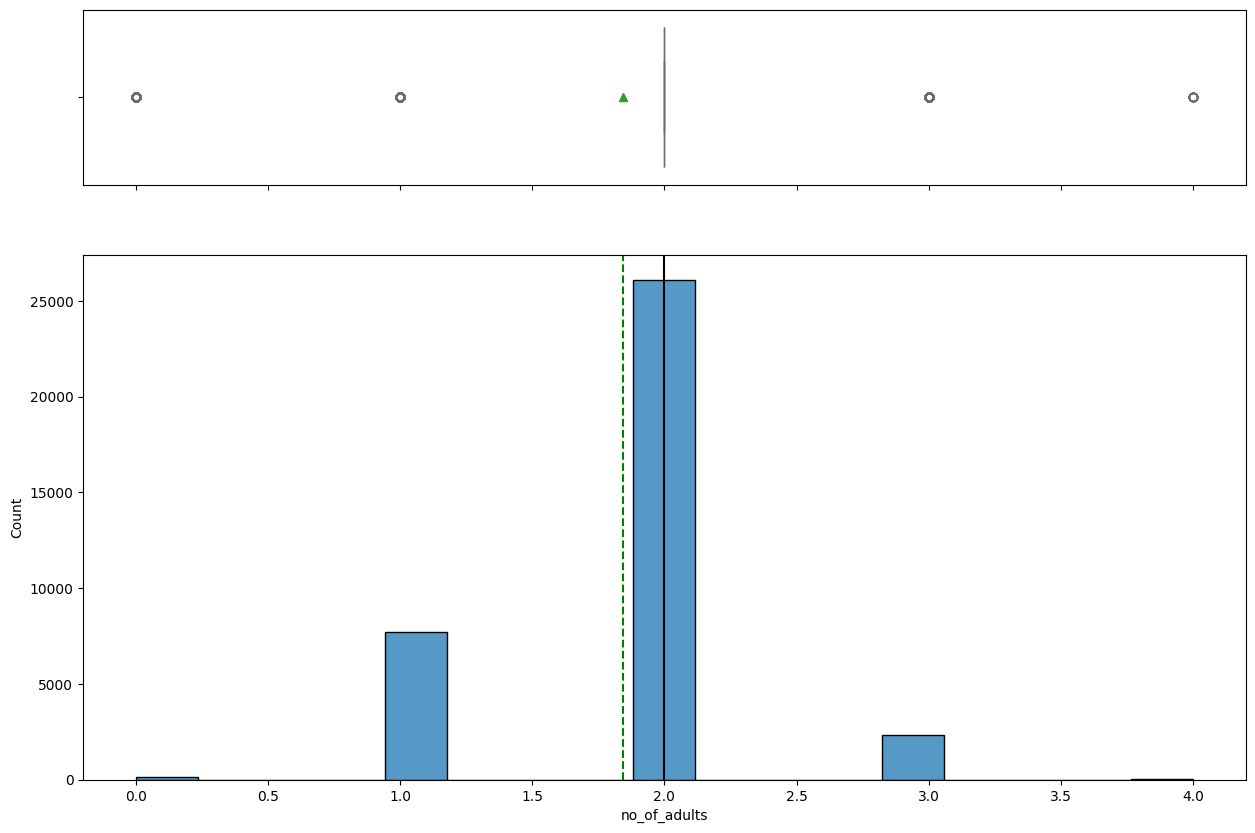

In [344]:
histogram_boxplot(data, "no_of_adults")

- The distribution for no_of_adults is highly concentrated on median with outliers on both ends of the distribution.
- The median value is 2.

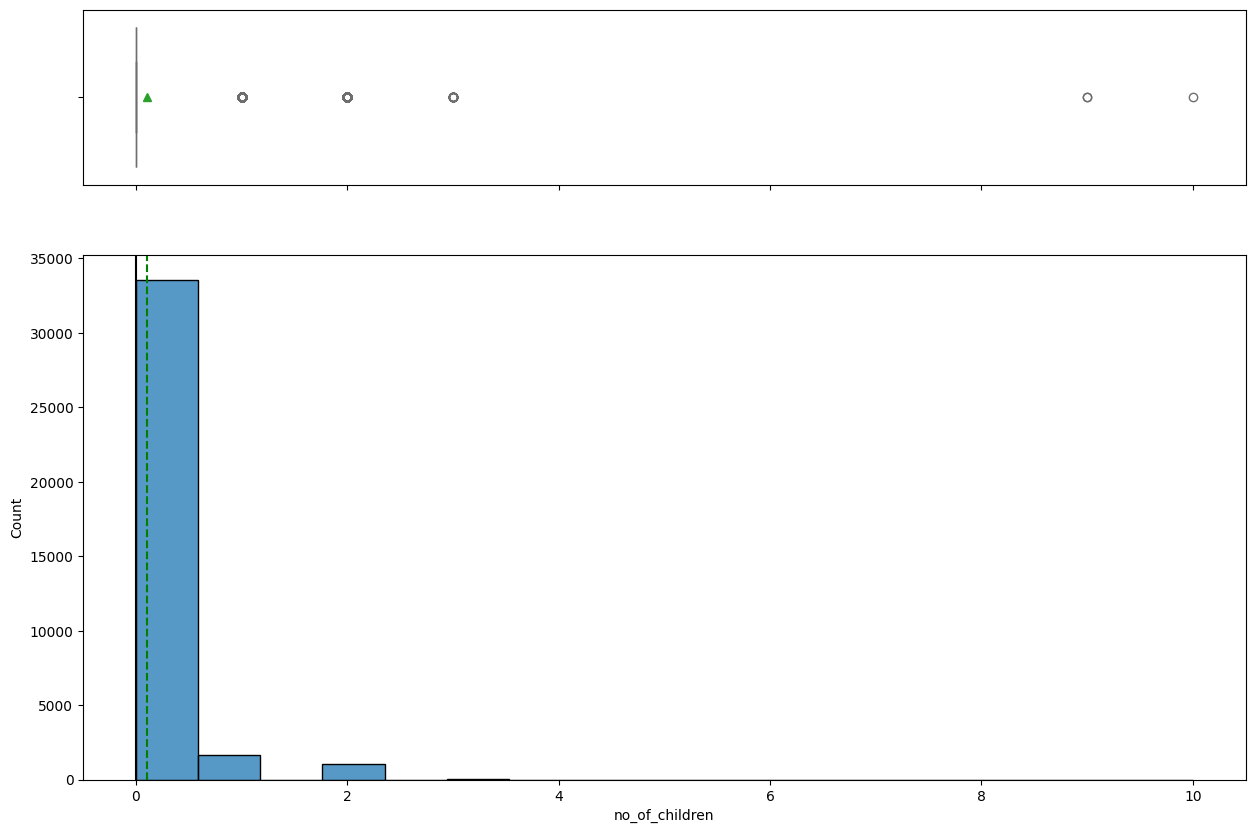

In [345]:
histogram_boxplot(data, "no_of_children")

- The distribution for no_of_children is slightly right skewed and highly concentrated on median with outliers on the right side of the distribution.
- The median value is 0.

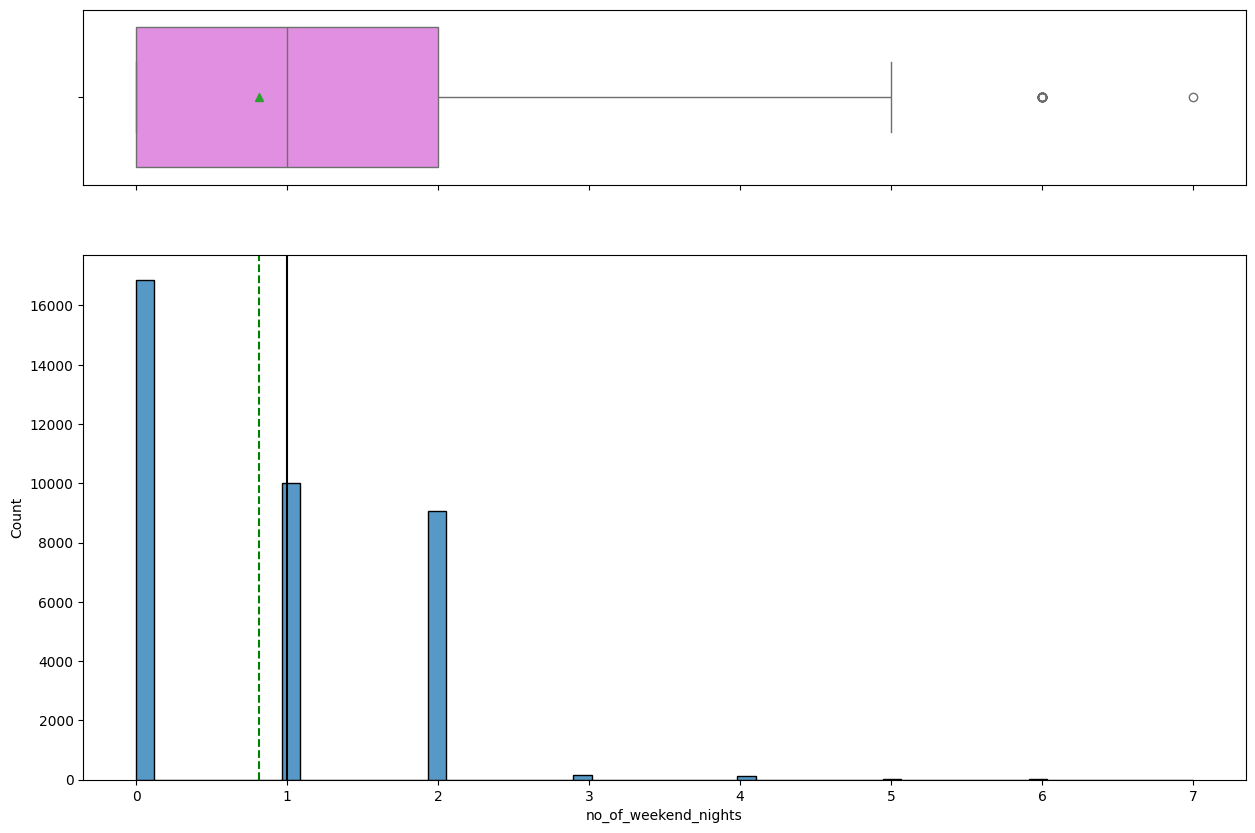

In [346]:
histogram_boxplot(data, "no_of_weekend_nights")

- The distribution for the no_of_weekend_nights is slightly left skewed, with the median of 1.
- There are outliers above the maximum value.

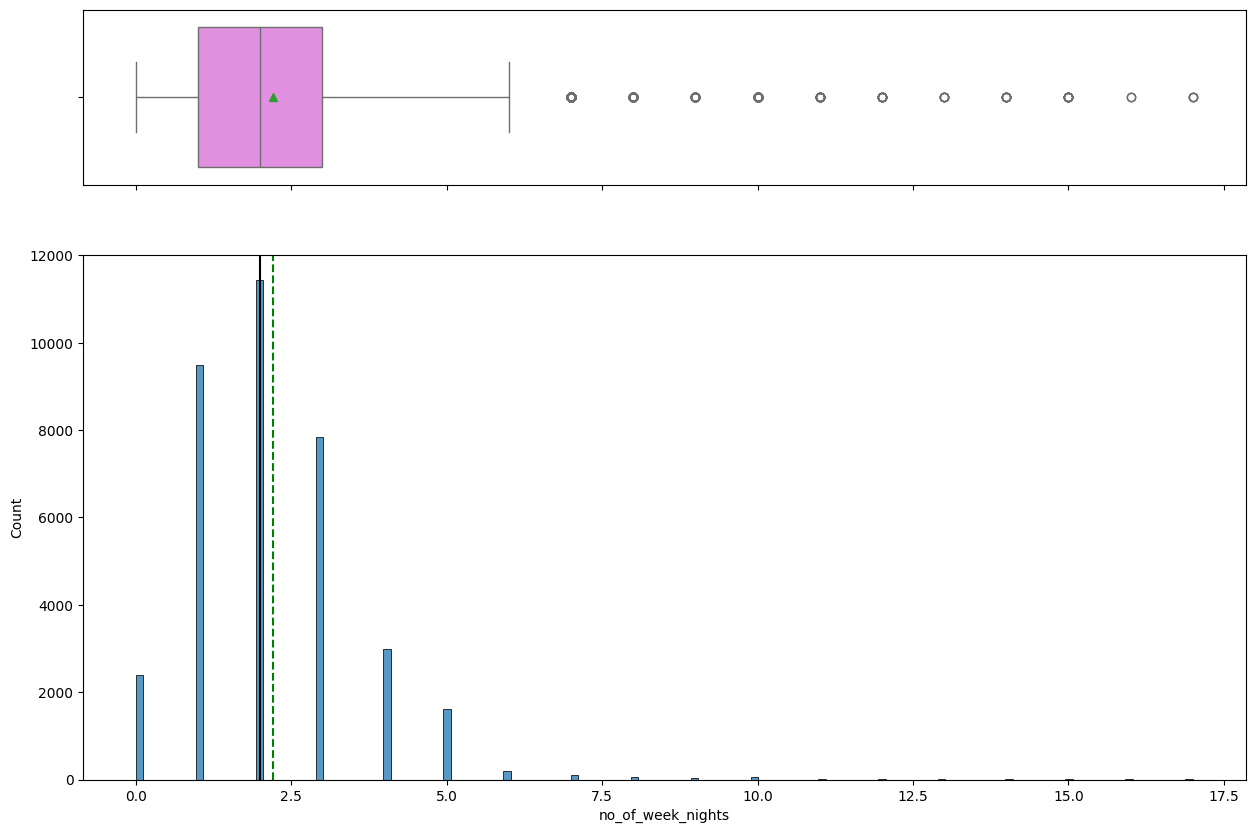

In [347]:
histogram_boxplot(data, "no_of_week_nights")

- The distribution for the no_of_week_nights is slightly right skewed, with the median of 2.
- There are outliers above the maximum value.

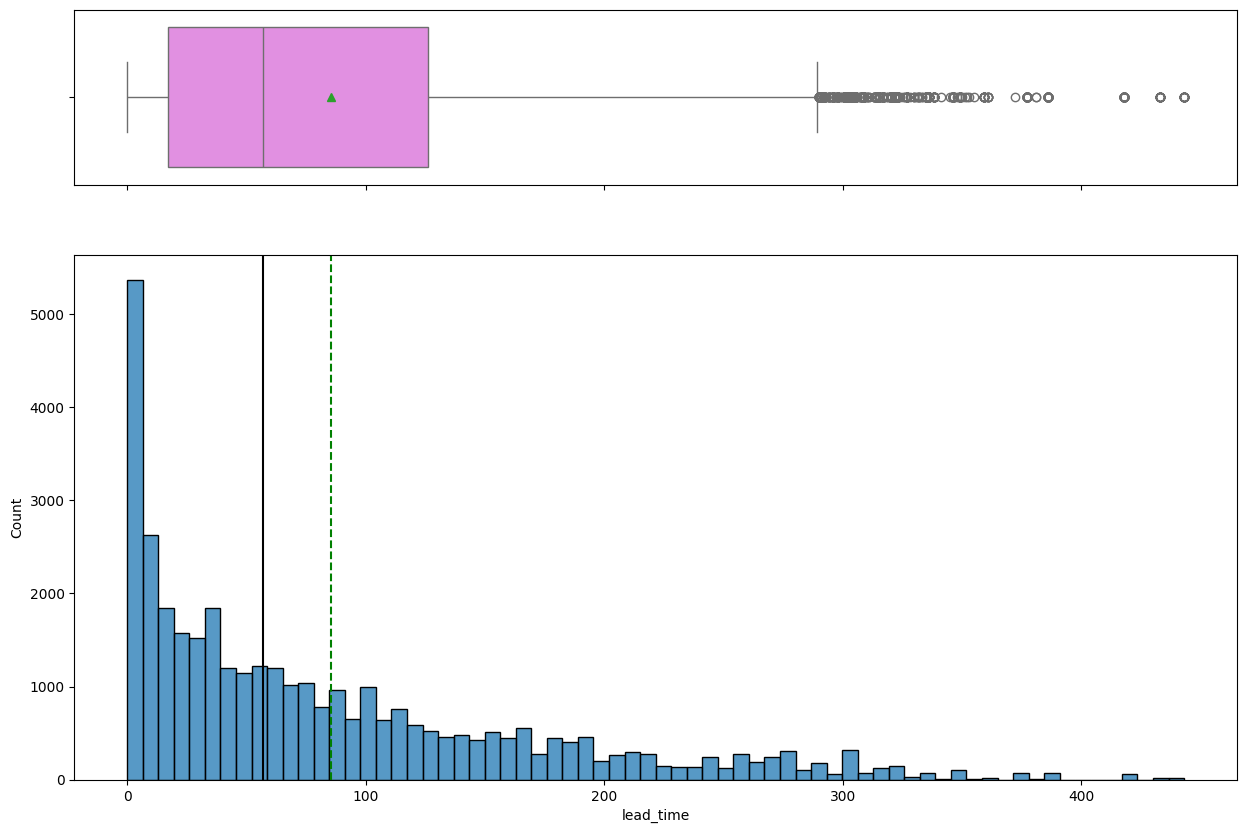

In [348]:
histogram_boxplot(data, "lead_time")

- The distribution for the lead_time is right skewed.
- There are outliers above the maximum value.

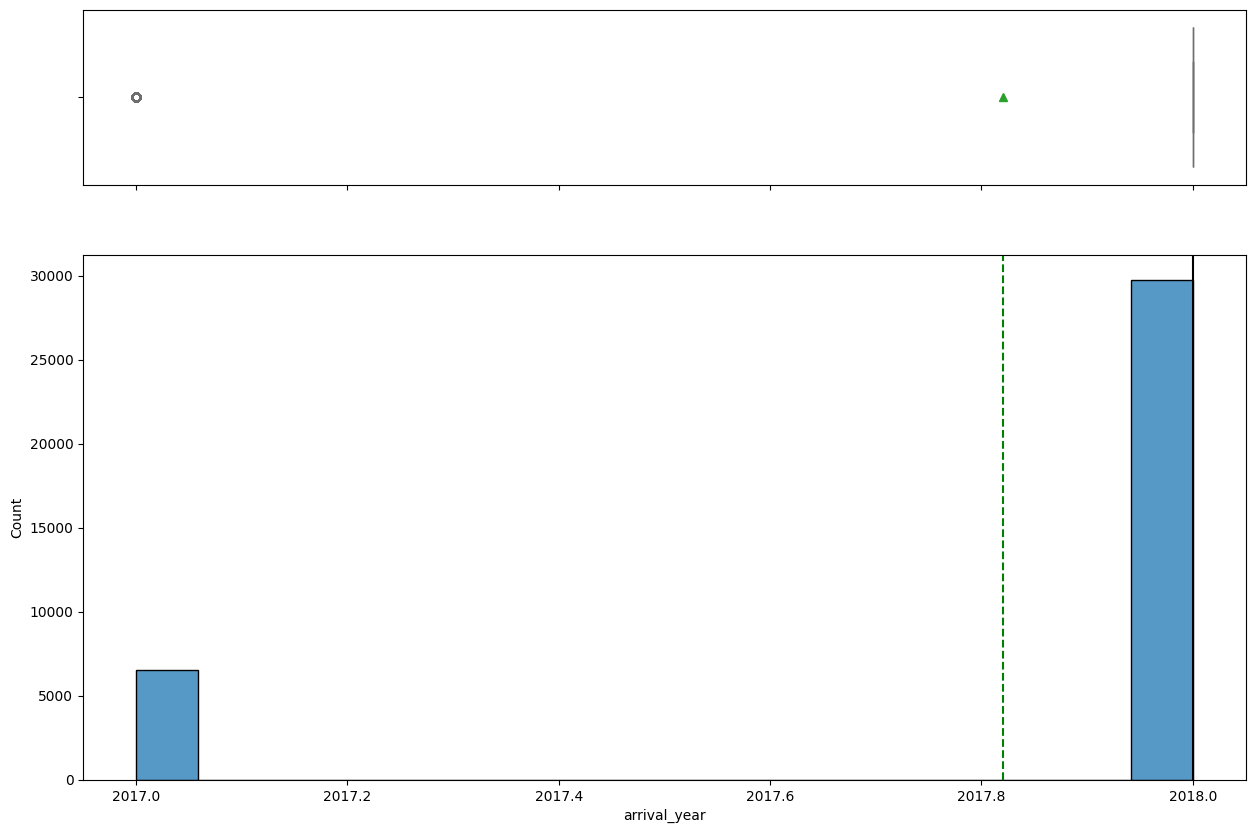

In [349]:
histogram_boxplot(data, "arrival_year")

- The distribution for the arrival_year is left skewed, with the median of 2018.
- There are outliers below the minimum value.

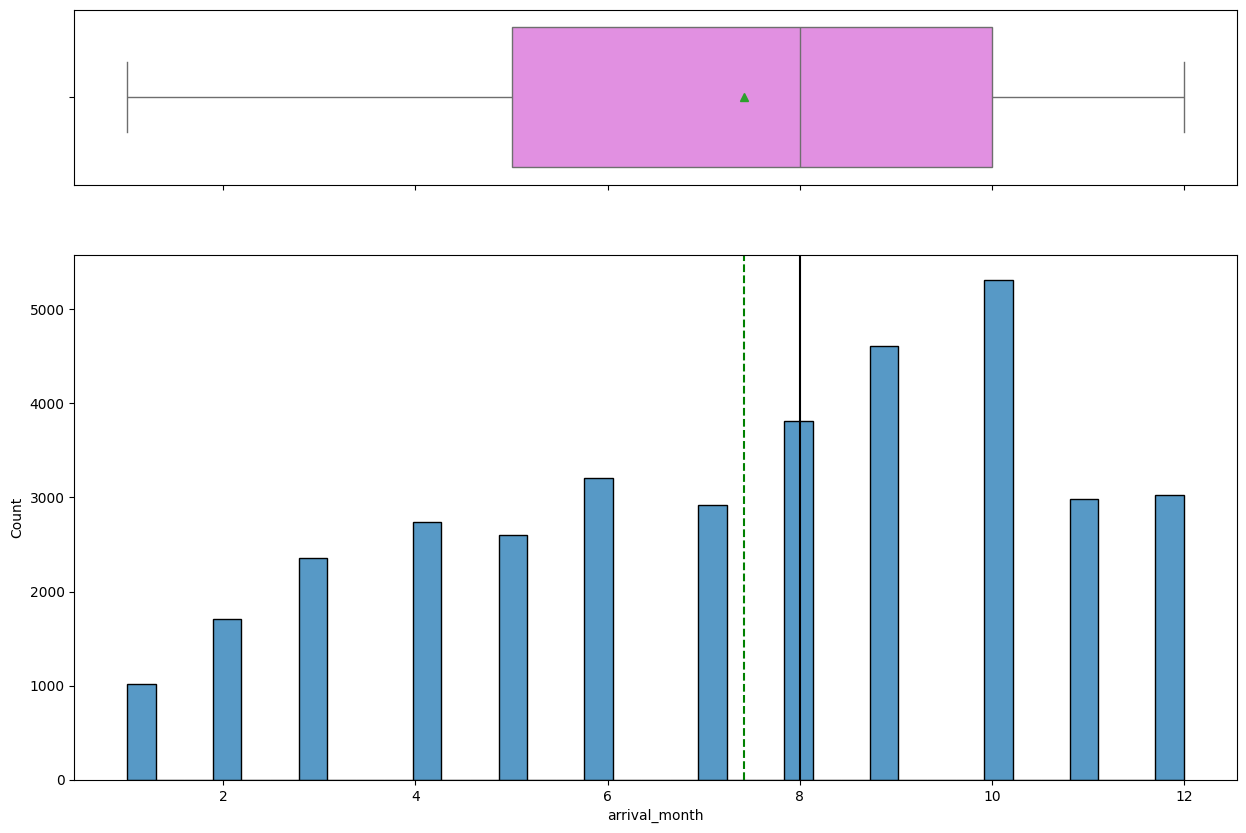

In [350]:
histogram_boxplot(data, "arrival_month")

- The distribution for the arrival_month is slightly left skewed, with the median of 8.
- August, Septempter, and October are the busiest months for the hotel.

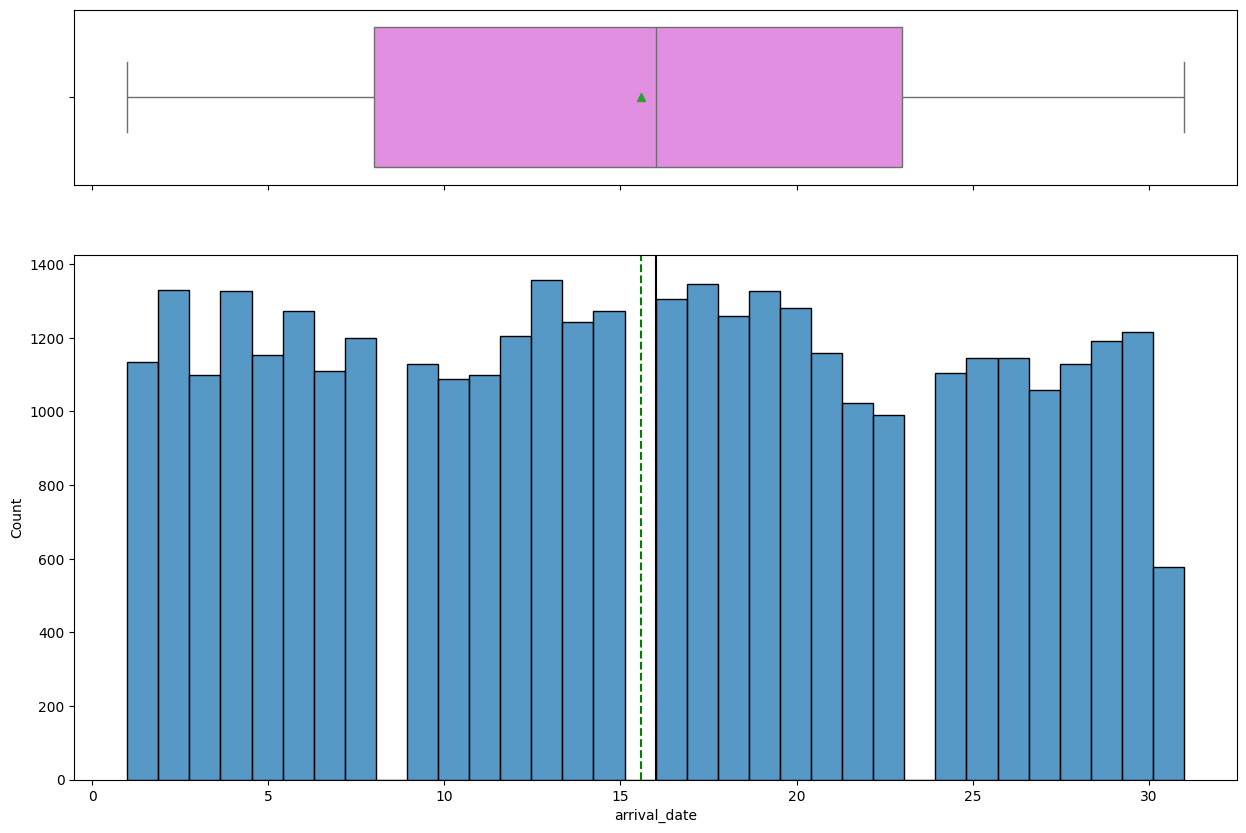

In [351]:
histogram_boxplot(data, "arrival_date")

- The arrival_date is almost uniformly distributed, with the median of 16.
- The arrival_date of 31 is smaller than the other dates because only 7 out of 12 months have 31 days.

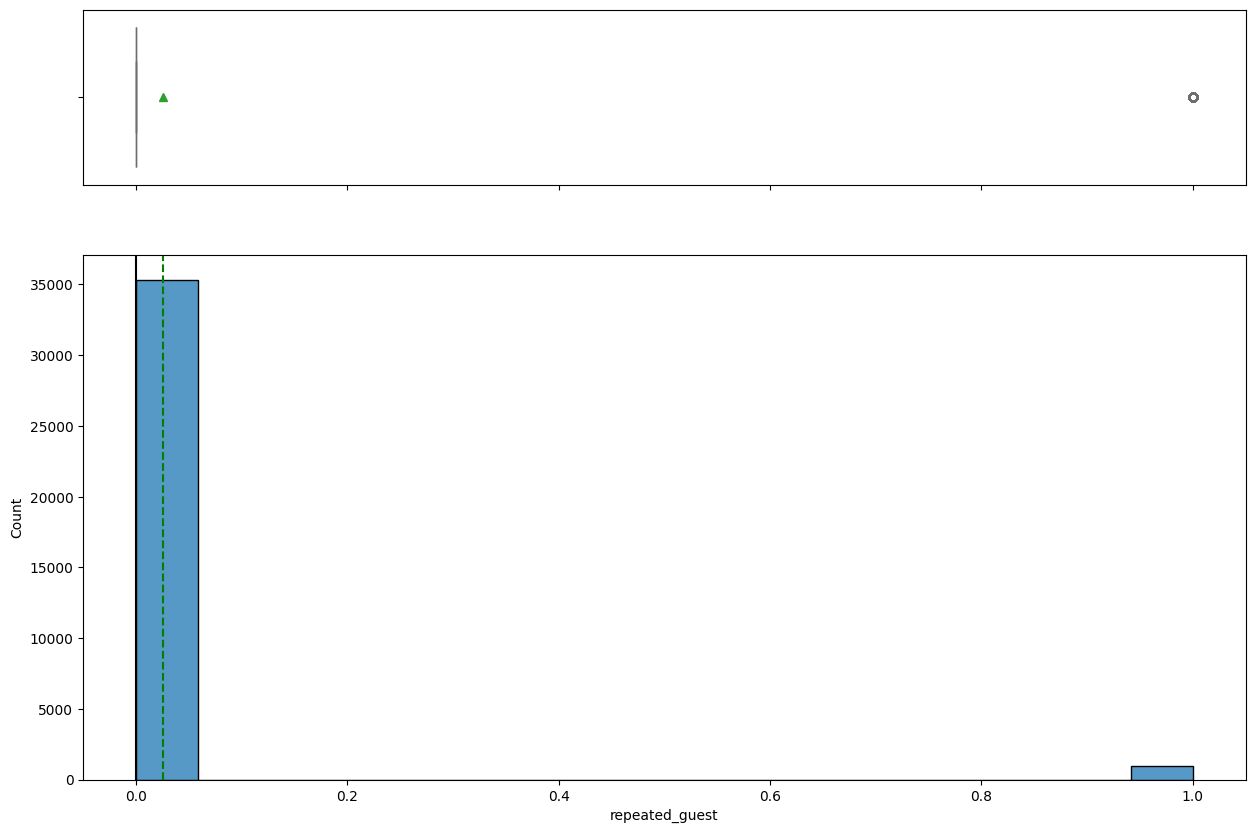

In [352]:
histogram_boxplot(data, "repeated_guest")

- The distribution for the repeated_guest is highly concentrated around the median of 0.

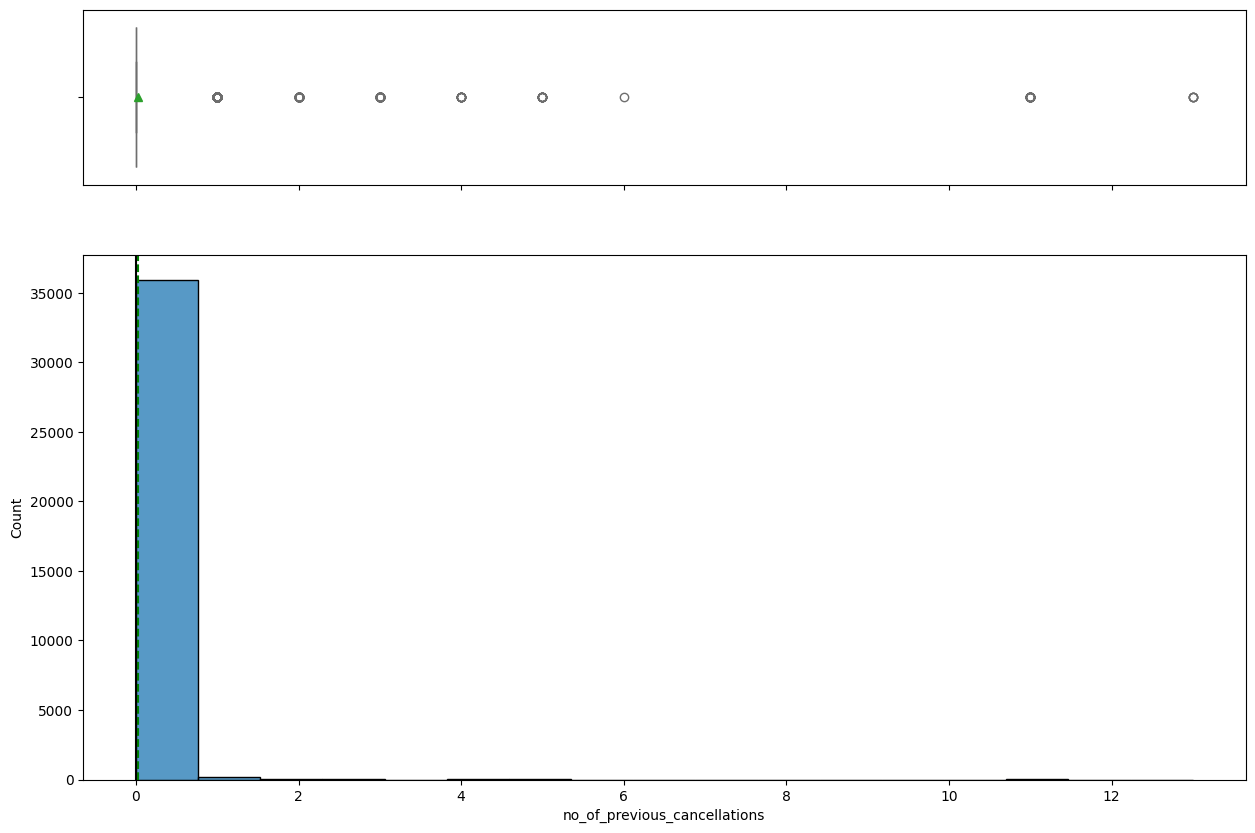

In [353]:
histogram_boxplot(data, "no_of_previous_cancellations")

- The distribution for the no_of_previous_cancellations is highly concentrated around the median of 0.
- There are outliers above the maximum value.

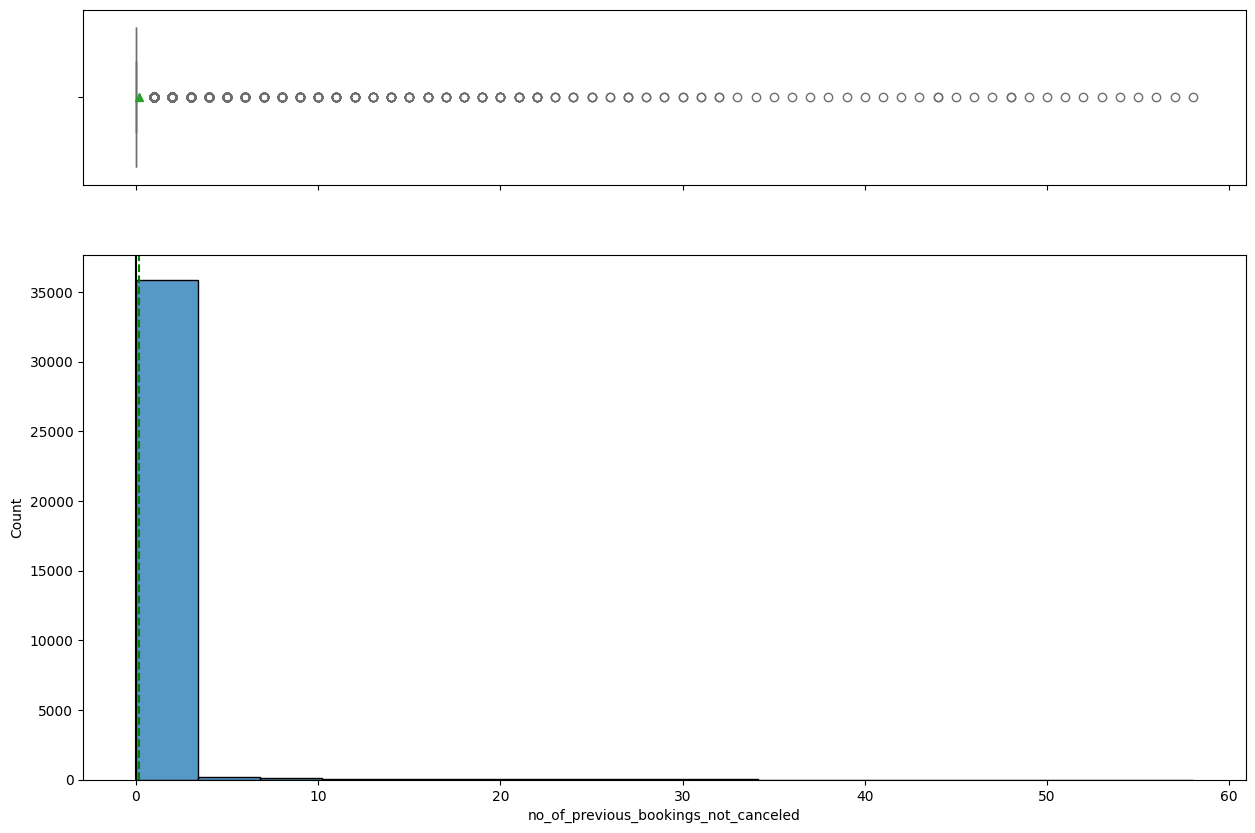

In [354]:
histogram_boxplot(data, "no_of_previous_bookings_not_canceled")

- The distribution for the no_of_previous_bookings_not_canceled is highly concentrated around the median of 0.
- There are outliers above the maximum value.

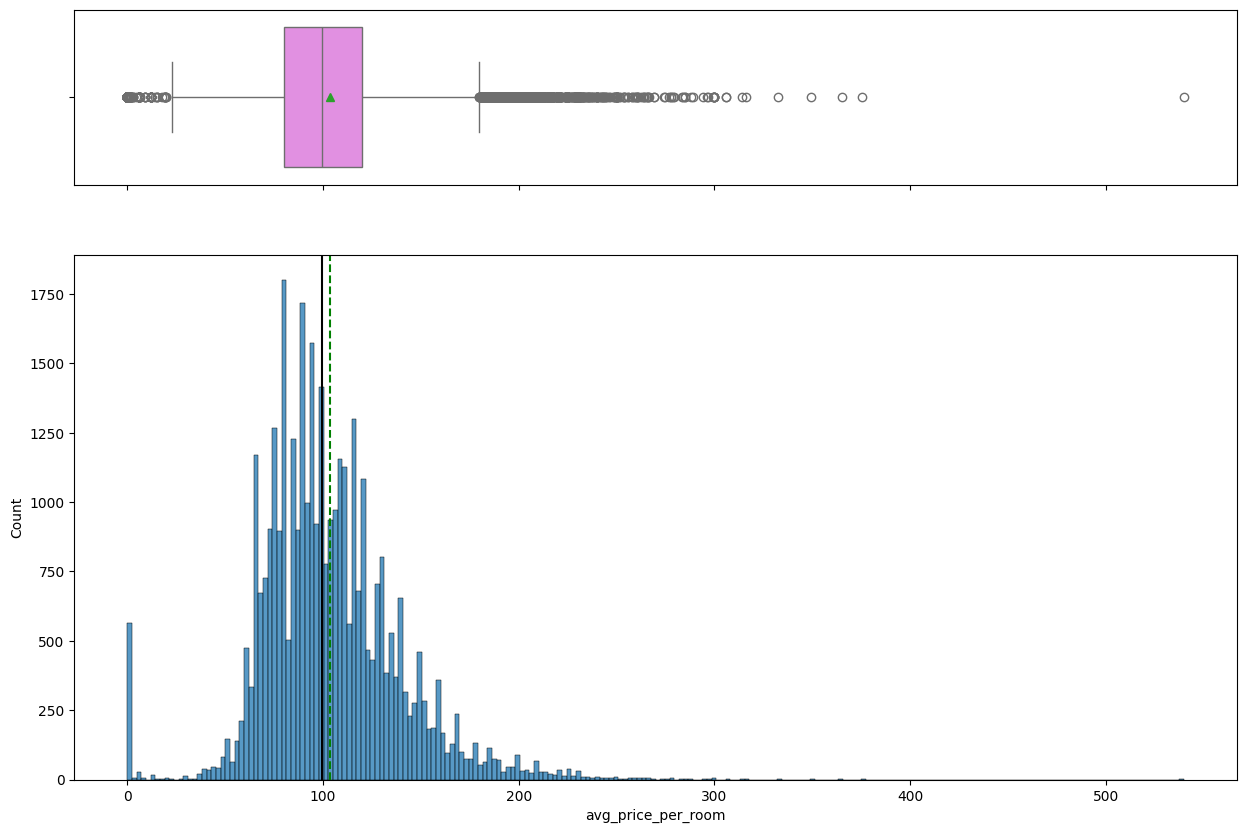

In [355]:
histogram_boxplot(data, "avg_price_per_room")

- The distribution for the avg_price_per_room is slightly right skewed.
- There are outliers on both ends of the distribution.


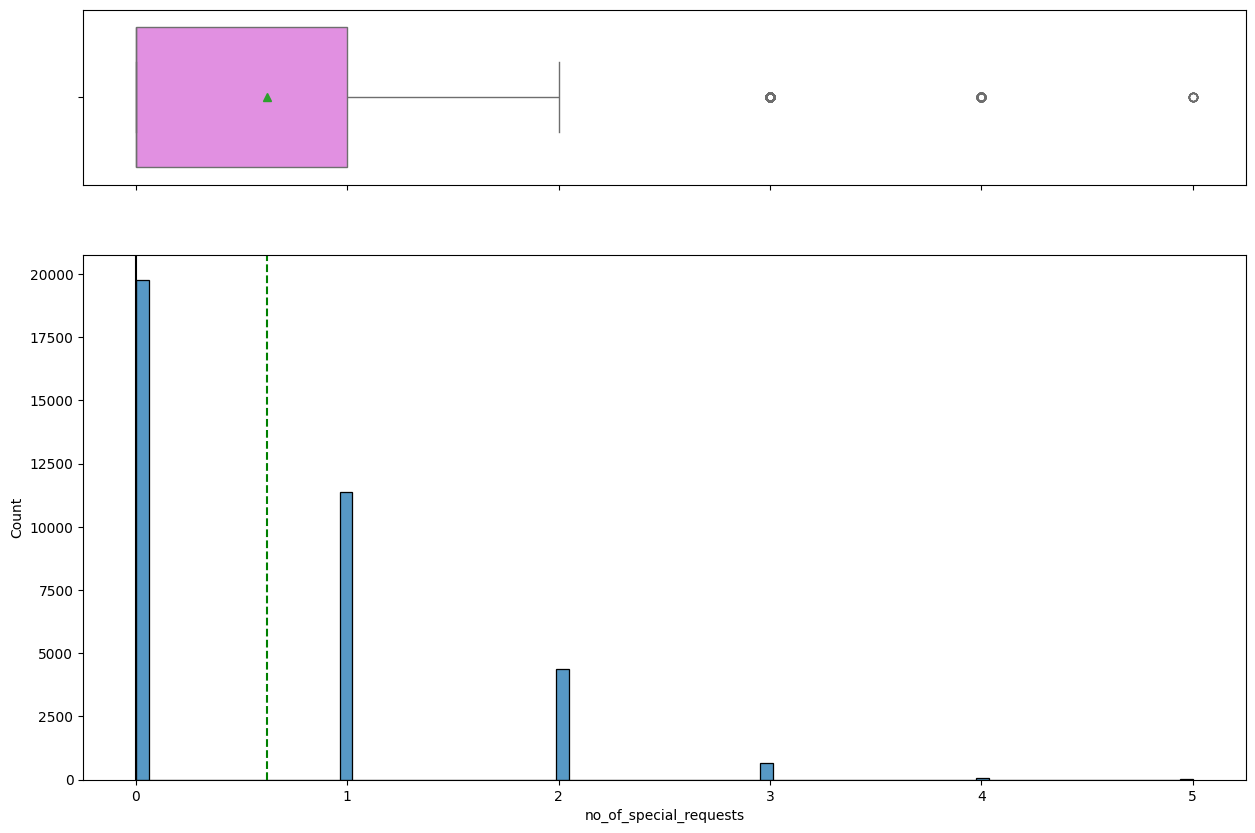

In [356]:
histogram_boxplot(data, "no_of_special_requests")

- The distribution for the no_of_special_guests is right skewed, with the median of 0.
- There are outliers above the maximum value.


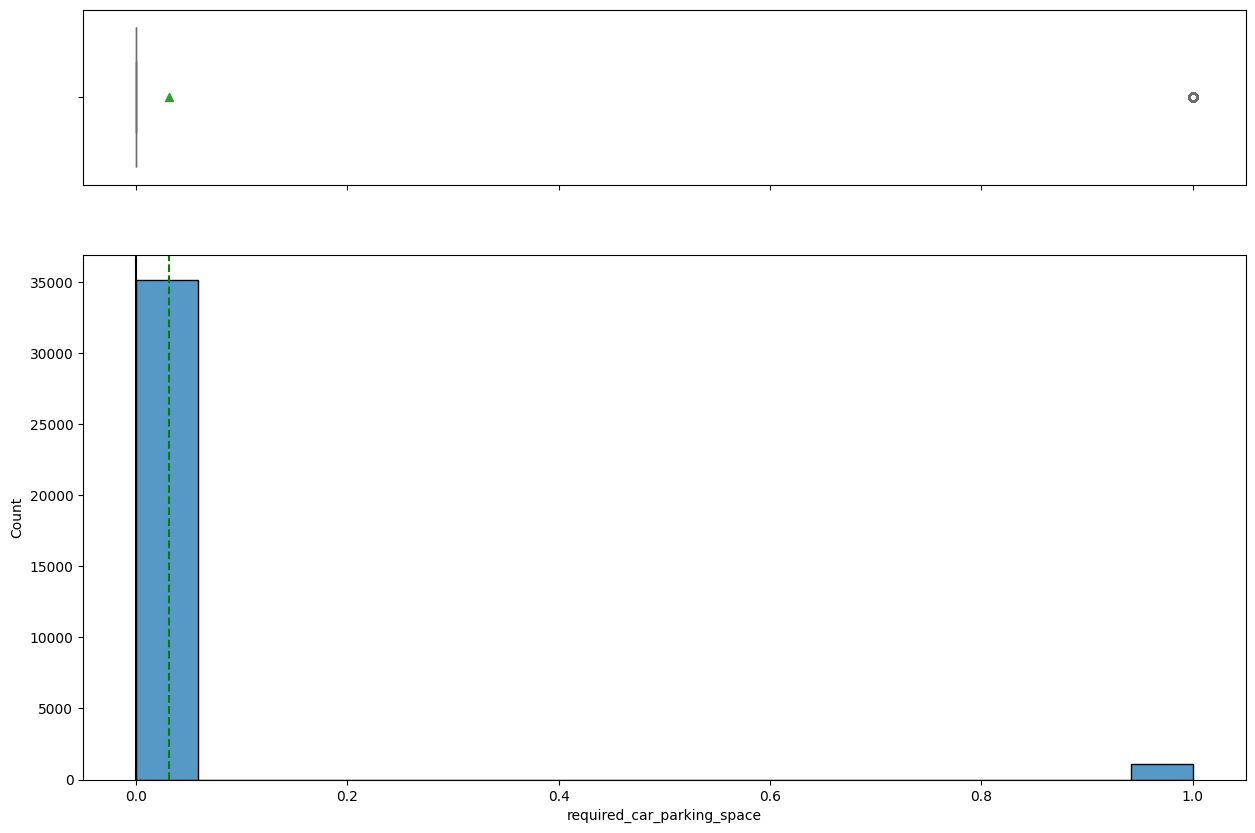

In [357]:
histogram_boxplot(data, "required_car_parking_space")

-	The distribution for the required_car_parking_space is slightly right skewed and highly concentrated around the median of 0.
-	There are outliers above the maximum value.


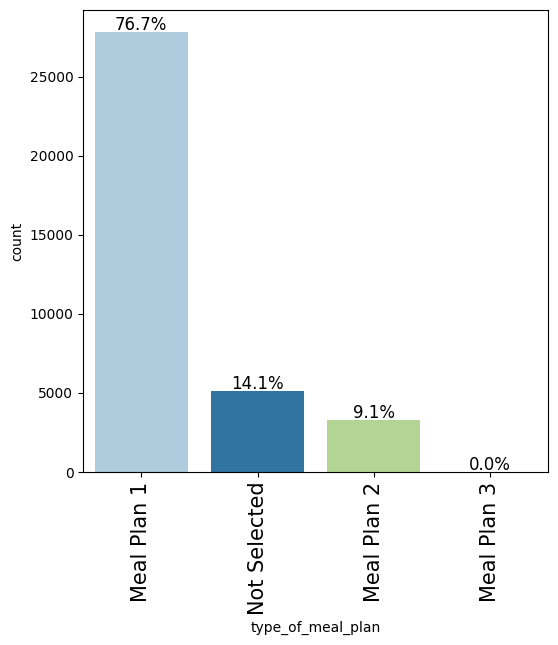

In [358]:
labeled_barplot(data, "type_of_meal_plan", perc=True)

* Meal Plan 1 has the highest percentage of the total meal plan types at 76.7%.

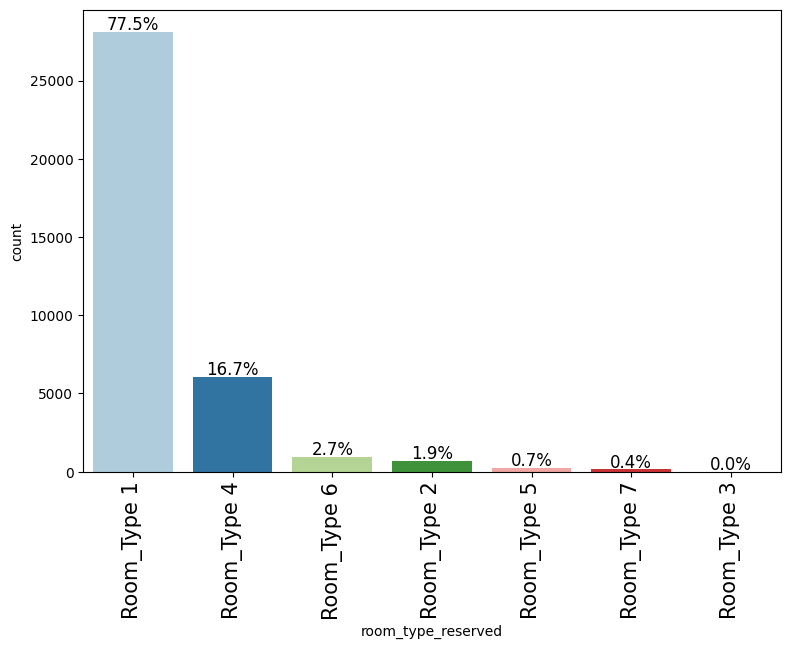

In [359]:
labeled_barplot(data, "room_type_reserved", perc=True)

* Room_Type_1 has the highest percentage of the total room types at 77.5%.

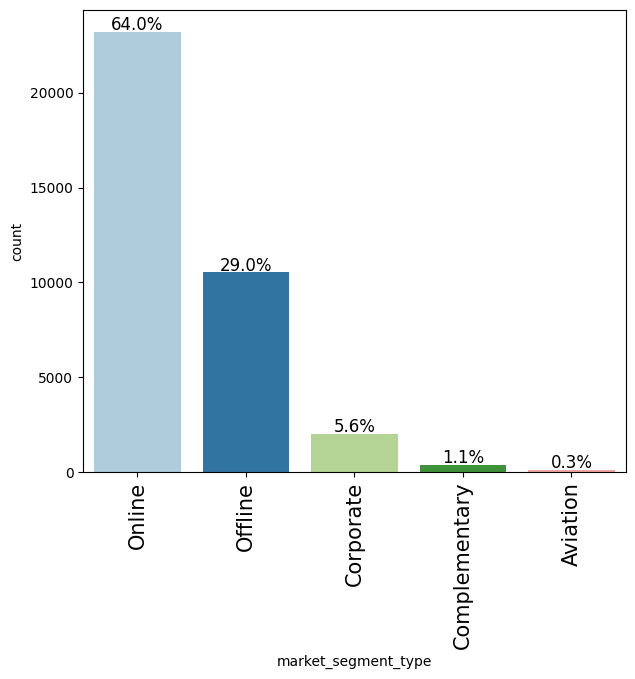

In [360]:
labeled_barplot(data, "market_segment_type", perc=True)

* Online has the highest percentage of the total market segment types at 64.0%, followed by Offline at 29.0%.

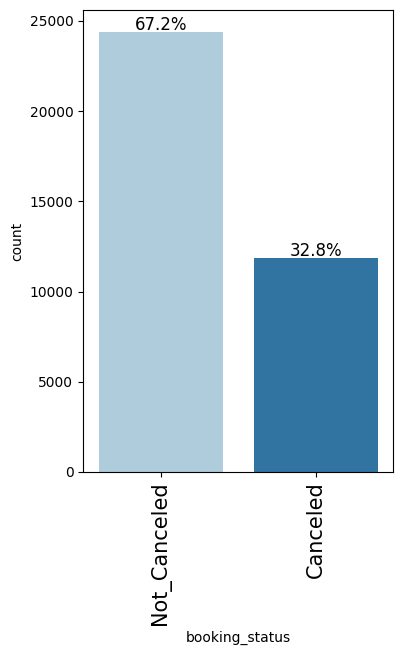

In [361]:
labeled_barplot(data, "booking_status", perc=True)

* Almost one-third (or 32.8%) of the guests canceled their booking, which presents a huge challenge for the hotel management.
* In order to perform a logistic regression analysis we will replace the categorical values with numeric values for the booking_status.

## Bivariate Analysis

### no_of_adults vs. booking_status

booking_status  Canceled  Not_Canceled    All
no_of_adults                                 
All                11885         24390  36275
2                   9119         16989  26108
1                   1856          5839   7695
3                    863          1454   2317
0                     44            95    139
4                      3            13     16
------------------------------------------------------------------------------------------------------------------------


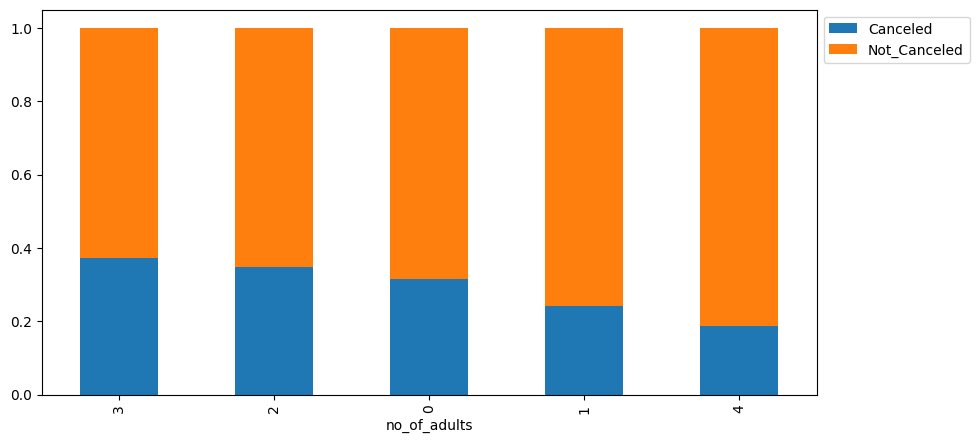

In [362]:
stacked_barplot(data, "no_of_adults", "booking_status")

* Guests with 3 adults have the most cancellations, followed by 2 and 0 adults.

### no_of_weekend_nights vs booking_status

booking_status        Canceled  Not_Canceled    All
no_of_weekend_nights                               
All                      11885         24390  36275
0                         5093         11779  16872
1                         3432          6563   9995
2                         3157          5914   9071
4                           83            46    129
3                           74            79    153
5                           29             5     34
6                           16             4     20
7                            1             0      1
------------------------------------------------------------------------------------------------------------------------


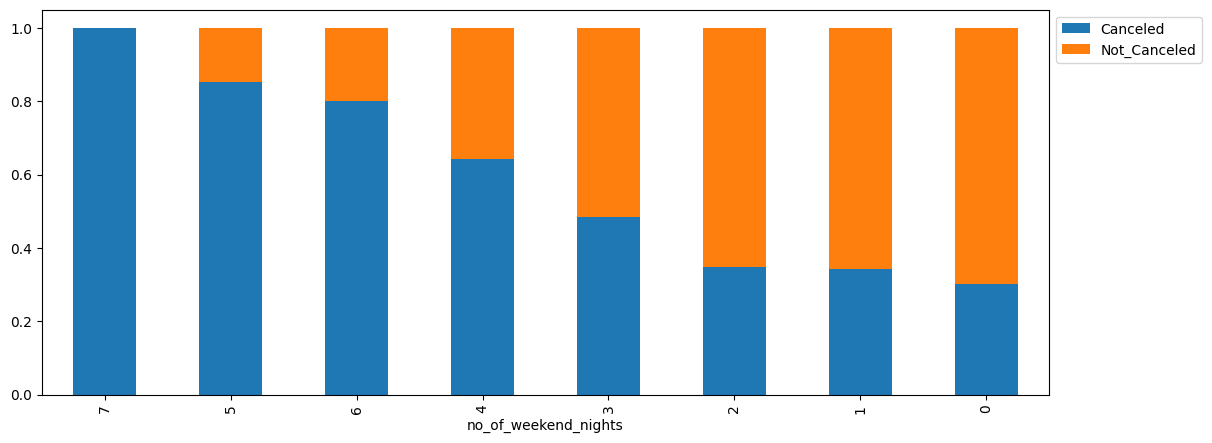

In [363]:
stacked_barplot(data, "no_of_weekend_nights", "booking_status")

* It appears that the no_of_weekend_nights and the booking_status have almost inverse relationship; the more weekend nights the guests books, the more likely they cancel their booking.

### no_of_week_nights vs booking_status

booking_status     Canceled  Not_Canceled    All
no_of_week_nights                               
All                   11885         24390  36275
2                      3997          7447  11444
3                      2574          5265   7839
1                      2572          6916   9488
4                      1143          1847   2990
0                       679          1708   2387
5                       632           982   1614
6                        88           101    189
10                       53             9     62
7                        52            61    113
8                        32            30     62
9                        21            13     34
11                       14             3     17
15                        8             2     10
12                        7             2      9
13                        5             0      5
14                        4             3      7
16                        2             0      2
17                  

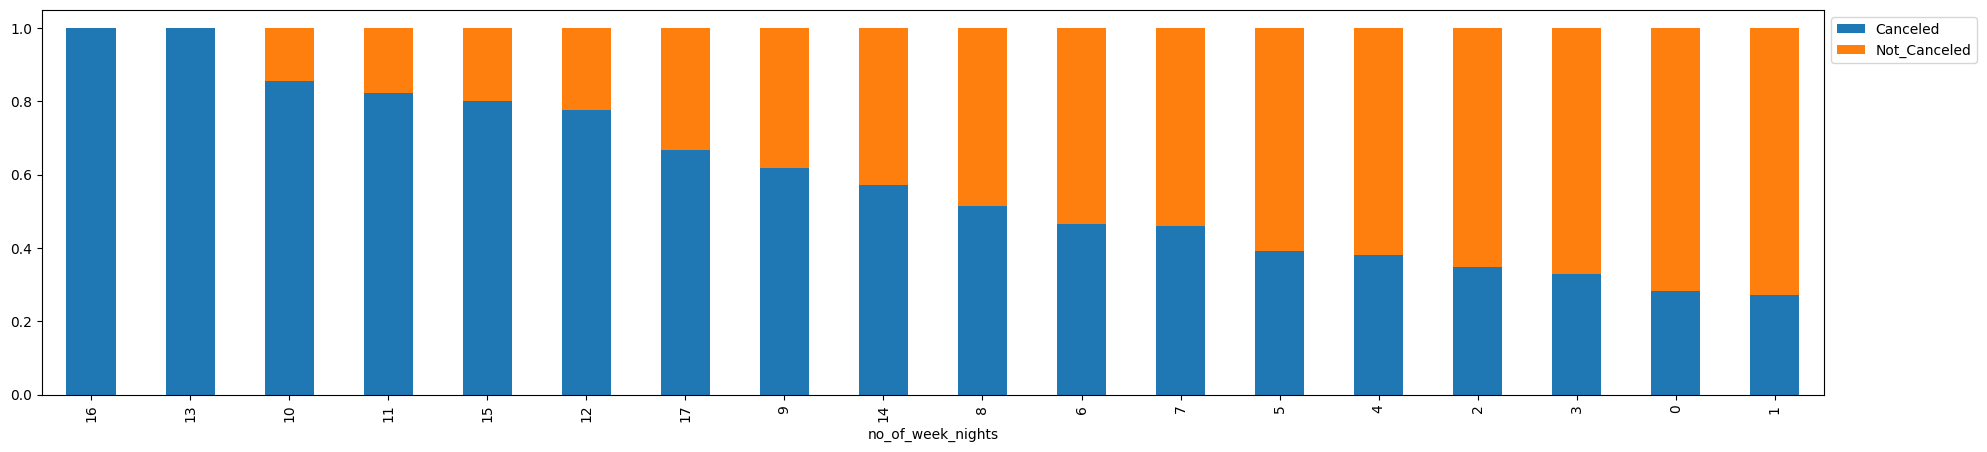

In [364]:
stacked_barplot(data, "no_of_week_nights", "booking_status")

* Similar to no_of_weekend_nights, no_of_week_nights have almost inverse relationship with booking_status; the more week nights the guests book, the more likely they cancel their booking.

### type_of_meal_plan vs booking_status

booking_status     Canceled  Not_Canceled    All
type_of_meal_plan                               
All                   11885         24390  36275
Meal Plan 1            8679         19156  27835
Not Selected           1699          3431   5130
Meal Plan 2            1506          1799   3305
Meal Plan 3               1             4      5
------------------------------------------------------------------------------------------------------------------------


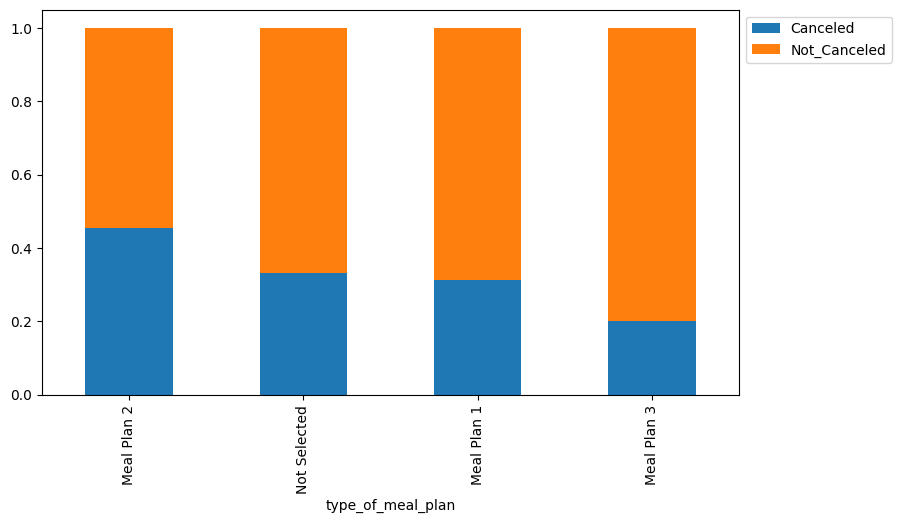

In [365]:
stacked_barplot(data, "type_of_meal_plan", "booking_status")

* Guests with Meal Plan 2 had the highest percentage of cancellation followed by Not Selected and Meal Plan 1.

### required_car_parking_space vs. booking_status

booking_status              Canceled  Not_Canceled    All
required_car_parking_space                               
All                            11885         24390  36275
0                              11771         23380  35151
1                                114          1010   1124
------------------------------------------------------------------------------------------------------------------------


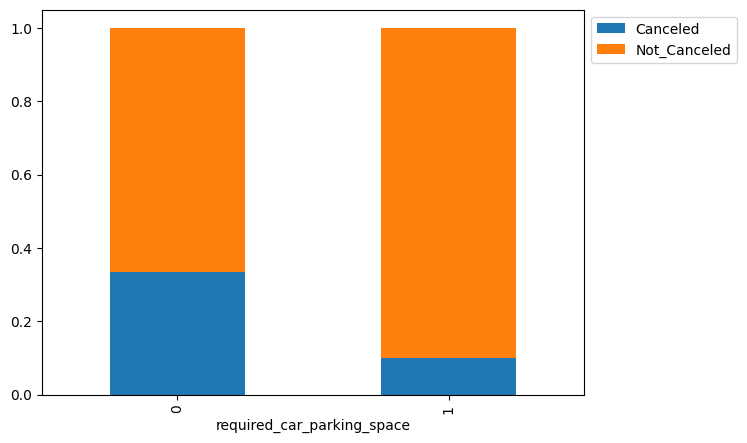

In [366]:
stacked_barplot(data, "required_car_parking_space", "booking_status")

* Guests with no required_car_parking_space had higher percentage of cancellation than guests with 1 required_car_parking_space.

### room_type_reserved vs booking_status

booking_status      Canceled  Not_Canceled    All
room_type_reserved                               
All                    11885         24390  36275
Room_Type 1             9072         19058  28130
Room_Type 4             2069          3988   6057
Room_Type 6              406           560    966
Room_Type 2              228           464    692
Room_Type 5               72           193    265
Room_Type 7               36           122    158
Room_Type 3                2             5      7
------------------------------------------------------------------------------------------------------------------------


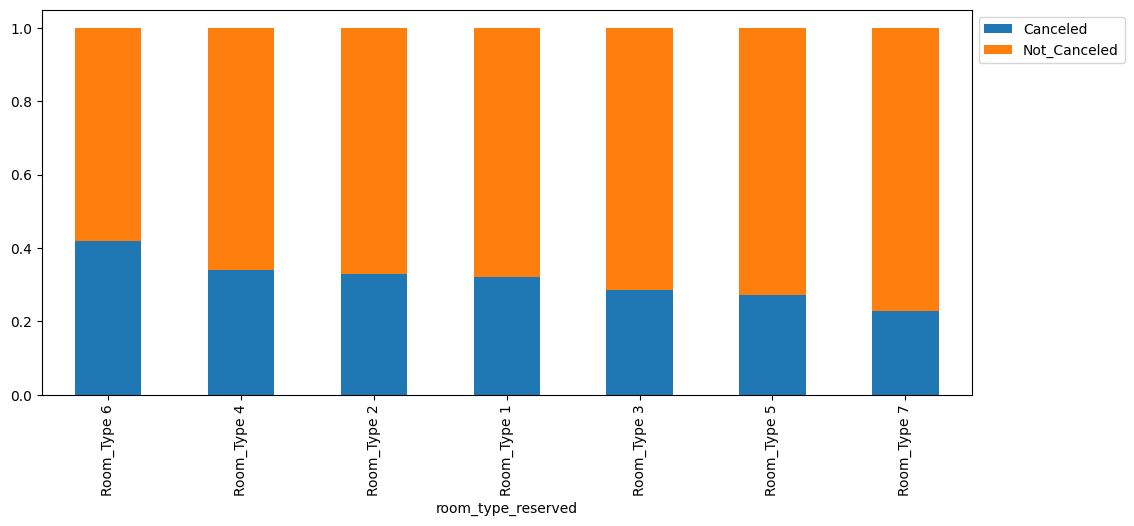

In [367]:
stacked_barplot(data, "room_type_reserved", "booking_status")

* Guests with Room_Type 6 had the highest percentage of cancellation followed by Room_Type 4 and Room_Type 2.

### Lead_time vs booking_status

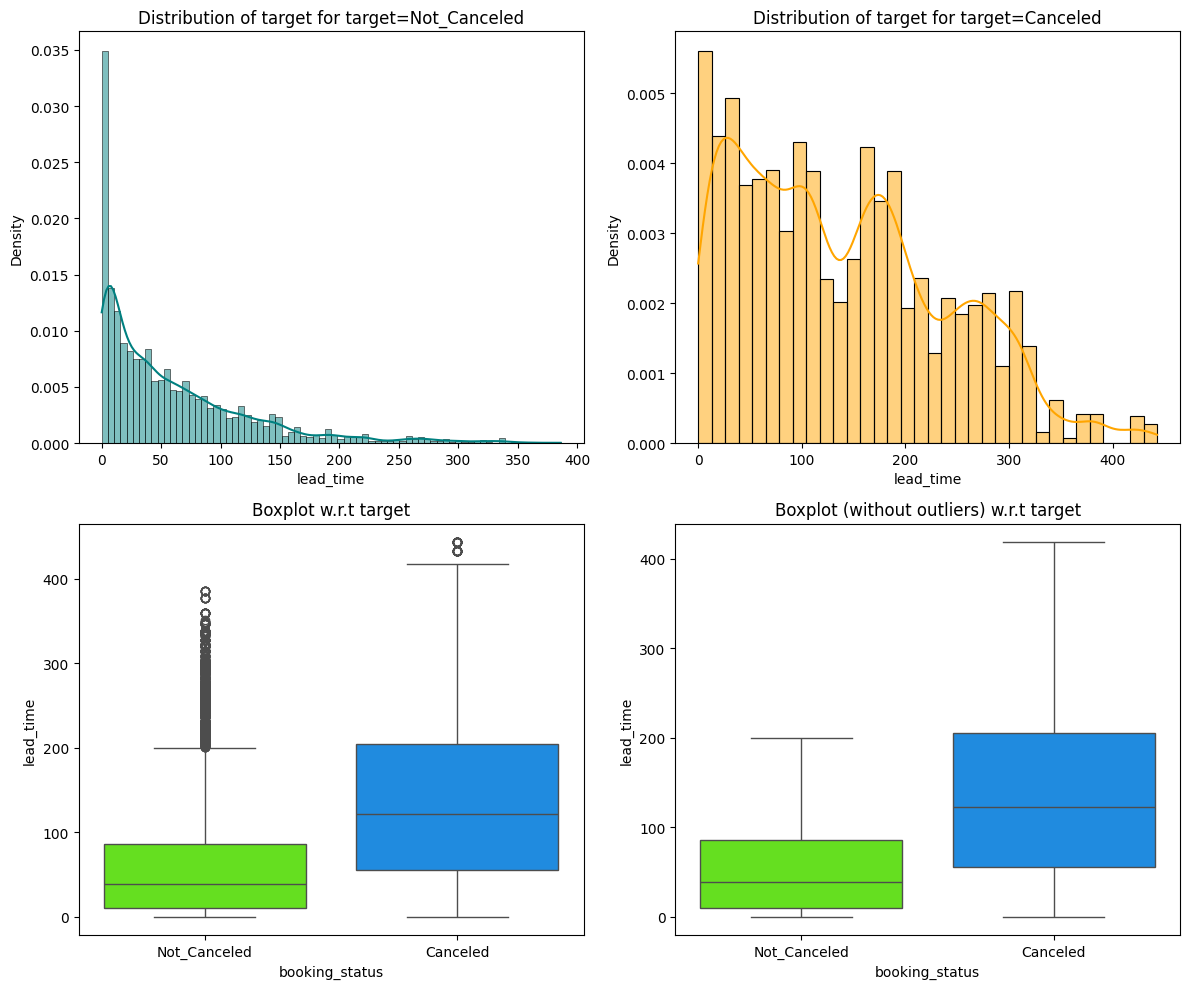

In [368]:
# let's visualize the relationship between lead_time and booking_status
distribution_plot_wrt_target(data, "lead_time", "booking_status")

* Boxbplots with and without outliers both show that bookings that are canceled have longer mean lead time than those that are not canceled.

### arrival_year vs booking_status

booking_status  Canceled  Not_Canceled    All
arrival_year                                 
All                11885         24390  36275
2018               10924         18837  29761
2017                 961          5553   6514
------------------------------------------------------------------------------------------------------------------------


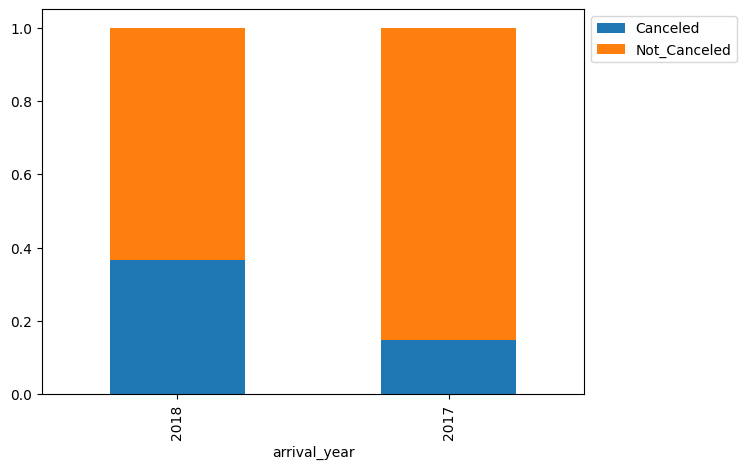

In [369]:
stacked_barplot(data, "arrival_year", "booking_status")

* 2018 had higher percentage of cancellation than 2017, which is a concerning trend for the hotel management.

### arrival_month vs booking_status

booking_status  Canceled  Not_Canceled    All
arrival_month                                
All                11885         24390  36275
10                  1880          3437   5317
9                   1538          3073   4611
8                   1488          2325   3813
7                   1314          1606   2920
6                   1291          1912   3203
4                    995          1741   2736
5                    948          1650   2598
11                   875          2105   2980
3                    700          1658   2358
2                    430          1274   1704
12                   402          2619   3021
1                     24           990   1014
------------------------------------------------------------------------------------------------------------------------


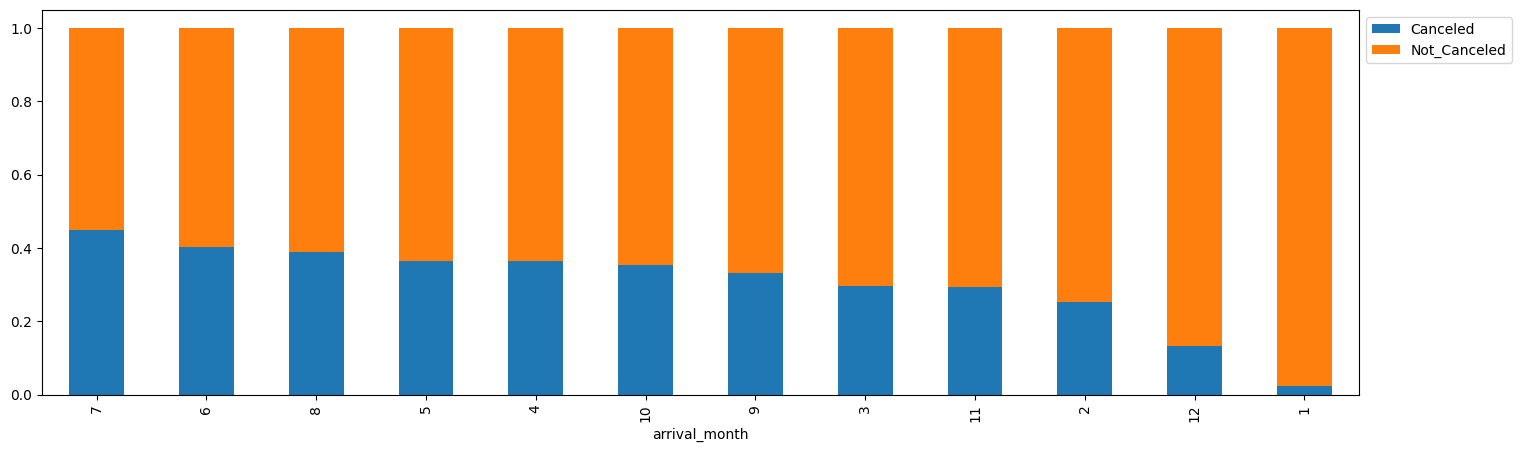

In [370]:
stacked_barplot(data, "arrival_month", "booking_status")

* Summer months (6-8) had the highest percentage of cancellation while the winter months (12-2) had the lowest percentage of cancellation.

### arrival_date vs booking_status

booking_status  Canceled  Not_Canceled    All
arrival_date                                 
All                11885         24390  36275
15                   538           735   1273
4                    474           853   1327
16                   473           833   1306
30                   465           751   1216
1                    465           668   1133
12                   460           744   1204
17                   448           897   1345
6                    444           829   1273
26                   425           721   1146
19                   413           914   1327
20                   413           868   1281
13                   408           950   1358
28                   405           724   1129
3                    403           695   1098
25                   395           751   1146
21                   376           782   1158
24                   372           731   1103
18                   366           894   1260
7                    364          

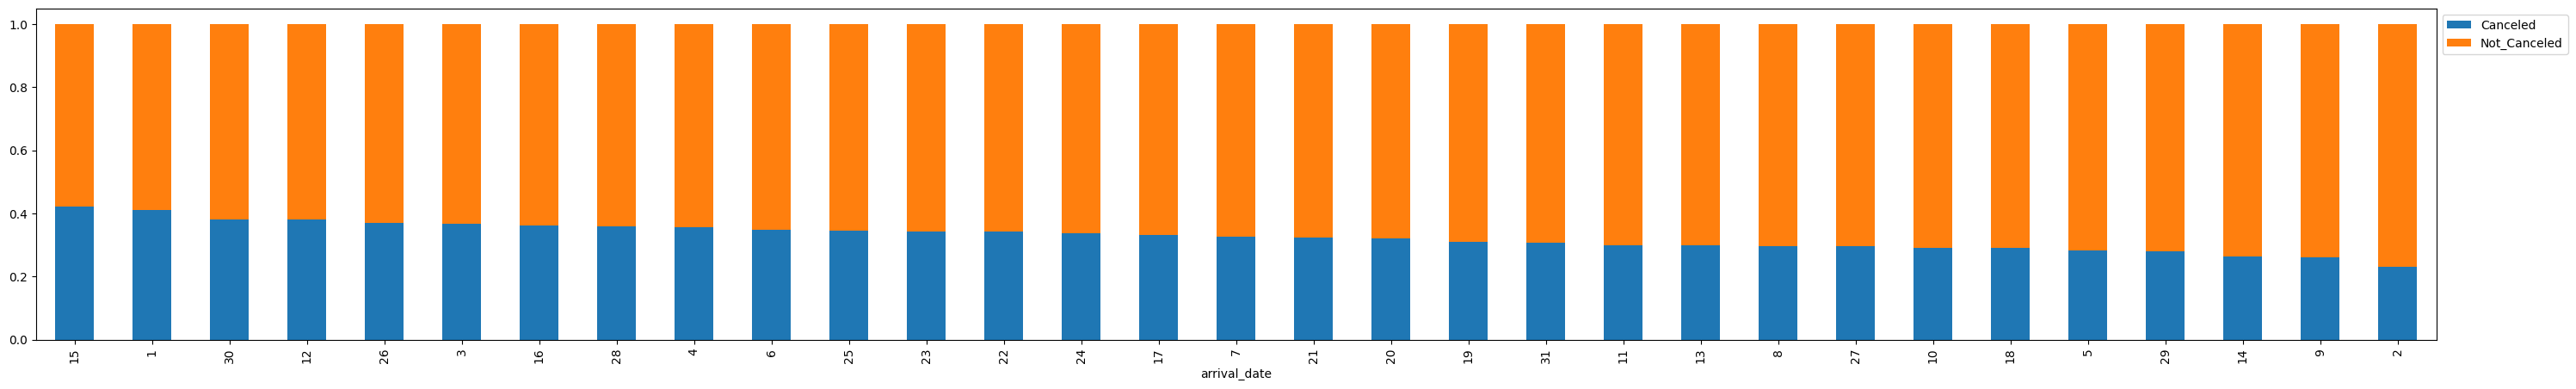

In [371]:
stacked_barplot(data, "arrival_date", "booking_status")

* 15 had the highest percentage of cancellation followed by 1 and 30.

### market_segment_type vs booking_status

booking_status       Canceled  Not_Canceled    All
market_segment_type                               
All                     11885         24390  36275
Online                   8475         14739  23214
Offline                  3153          7375  10528
Corporate                 220          1797   2017
Aviation                   37            88    125
Complementary               0           391    391
------------------------------------------------------------------------------------------------------------------------


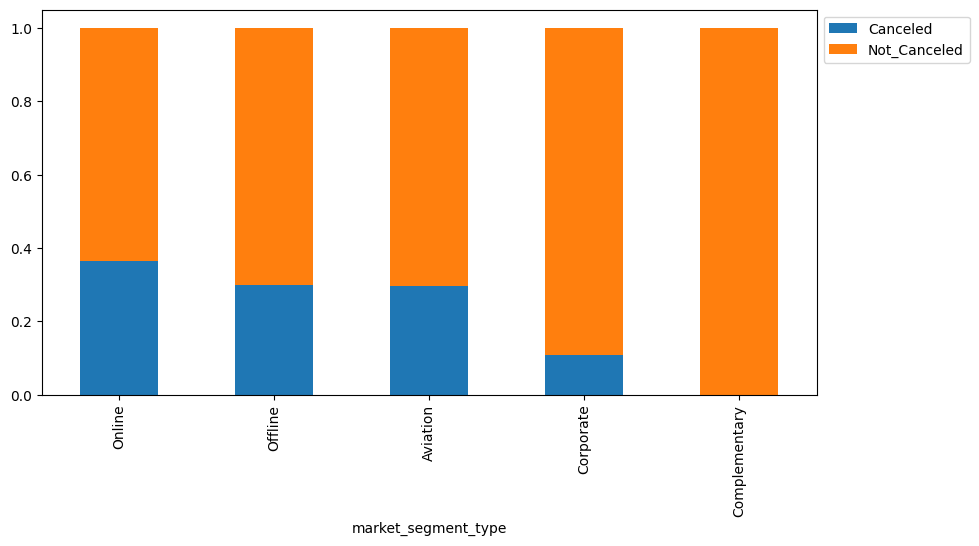

In [372]:
stacked_barplot(data, "market_segment_type", "booking_status")

* Online had the highest percentage of cancellation while Complementary had the lowest cancellation at 0%.

### market_segment_type vs avg_price_per_room

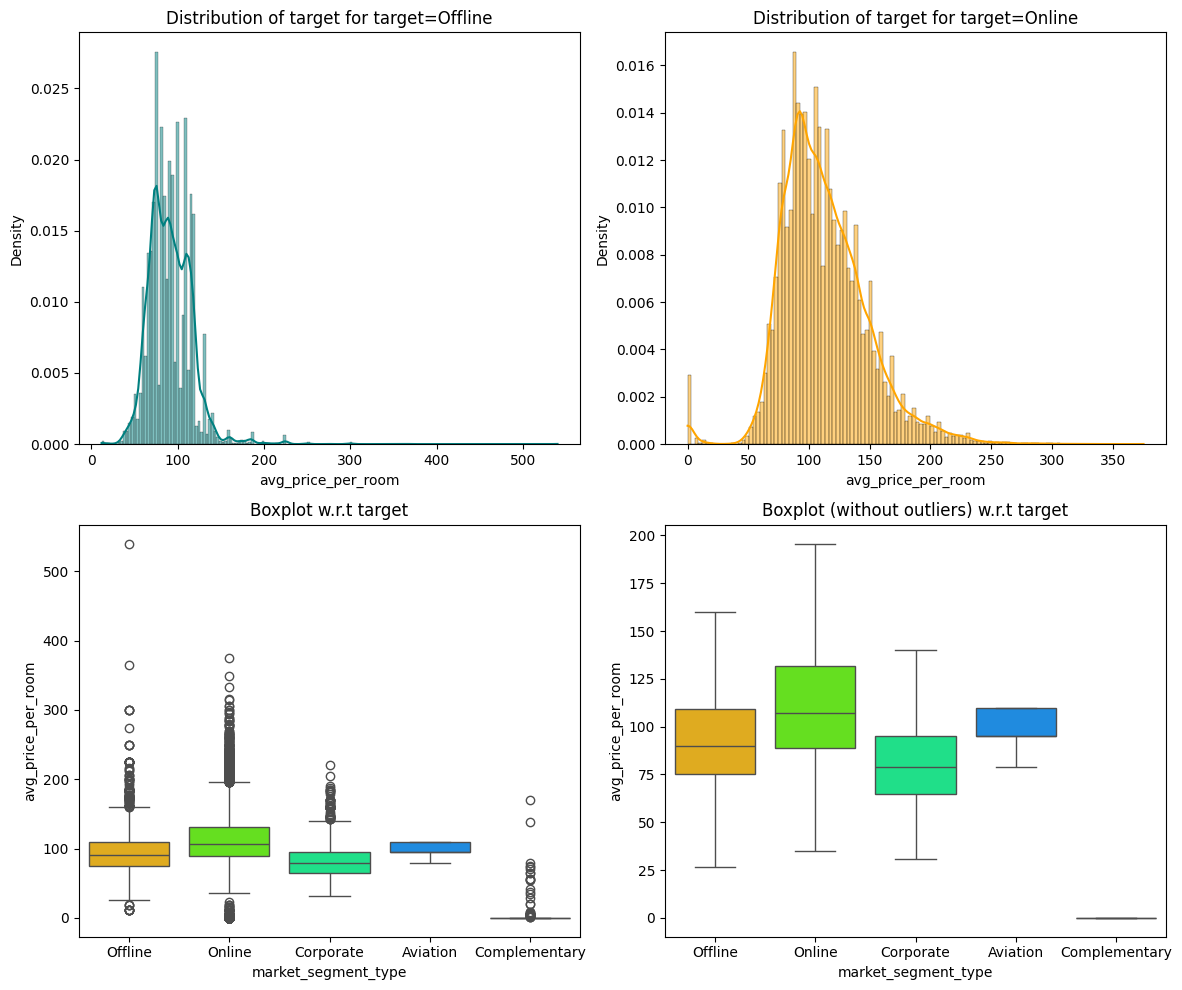

In [373]:
# let's visualize the relationship between market_segment_type vs avg_price_per_room
distribution_plot_wrt_target(data, "avg_price_per_room", "market_segment_type")

* Online segment has the highest average price per room both with and without outliers. This segment also has the biggest range of average price per room.

### repeated_guest vs booking status

booking_status  Canceled  Not_Canceled    All
repeated_guest                               
All                11885         24390  36275
0                  11869         23476  35345
1                     16           914    930
------------------------------------------------------------------------------------------------------------------------


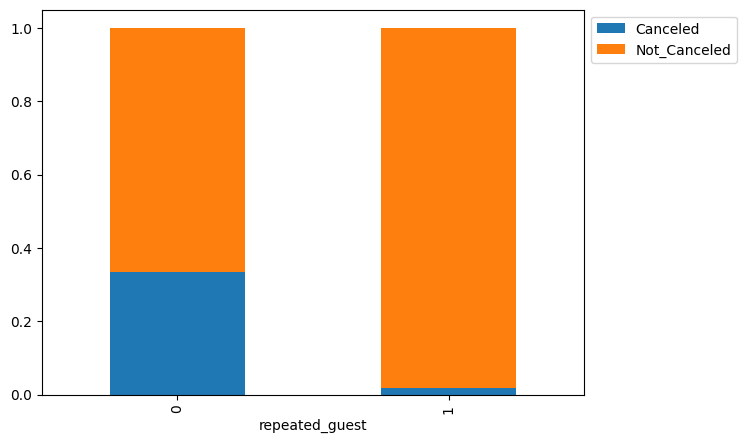

In [374]:
stacked_barplot(data, "repeated_guest", "booking_status")

* As expected, repeated guests had significantly lower rate of cancellation than non_repeated_guests.

### Percentage of repeated guests who cancel

In [375]:
# let's get the percentage of repeated_guests who cancel their booking
data.groupby("repeated_guest")["booking_status"].value_counts(normalize=True)

repeated_guest  booking_status
0               Not_Canceled     0.66420
                Canceled         0.33580
1               Not_Canceled     0.98280
                Canceled         0.01720
Name: proportion, dtype: float64

* As expected, only 1.7% of repeating guests cancel their booking, whereas 33.6% of nonrepeating guests cancel their booking.

### no_of_previous_cancellations vs booking_status

booking_status                Canceled  Not_Canceled    All
no_of_previous_cancellations                               
All                              11885         24390  36275
0                                11869         24068  35937
1                                   11           187    198
13                                   4             0      4
3                                    1            42     43
2                                    0            46     46
4                                    0            10     10
5                                    0            11     11
6                                    0             1      1
11                                   0            25     25
------------------------------------------------------------------------------------------------------------------------


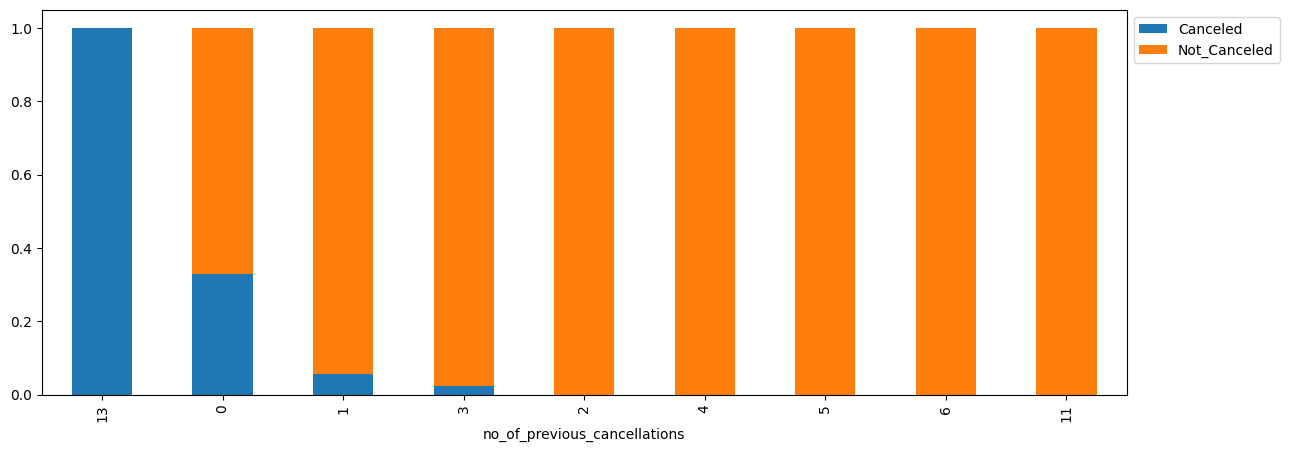

In [376]:
stacked_barplot(data, "no_of_previous_cancellations", "booking_status")

* Guests with 13 previous cancellations had the highest rate of cancellation at 100% followed by guests with 0 and 1 previous cancellations.

### no_of_previous_bookings_not_canceled vs booking_status

booking_status                        Canceled  Not_Canceled    All
no_of_previous_bookings_not_canceled                               
All                                      11885         24390  36275
0                                        11878         23585  35463
1                                            4           224    228
12                                           1            11     12
4                                            1            64     65
6                                            1            35     36
2                                            0           112    112
44                                           0             2      2
43                                           0             1      1
42                                           0             1      1
41                                           0             1      1
40                                           0             1      1
38                                           0  

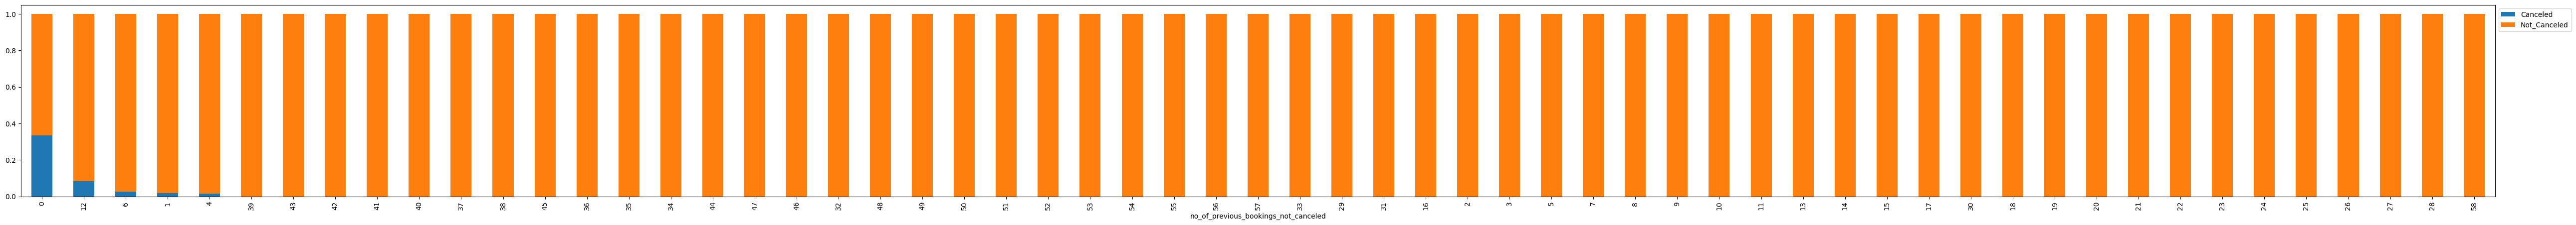

In [377]:
stacked_barplot(data, "no_of_previous_bookings_not_canceled", "booking_status")

* Guests with zero previous_bookings_not_canceled had the highest rate of cancellation followed by guests with 12 previous_bookings_not_canceled.

### no_of_special_requests vs booking_status

booking_status          Canceled  Not_Canceled    All
no_of_special_requests                               
All                        11885         24390  36275
0                           8545         11232  19777
1                           2703          8670  11373
2                            637          3727   4364
3                              0           675    675
4                              0            78     78
5                              0             8      8
------------------------------------------------------------------------------------------------------------------------


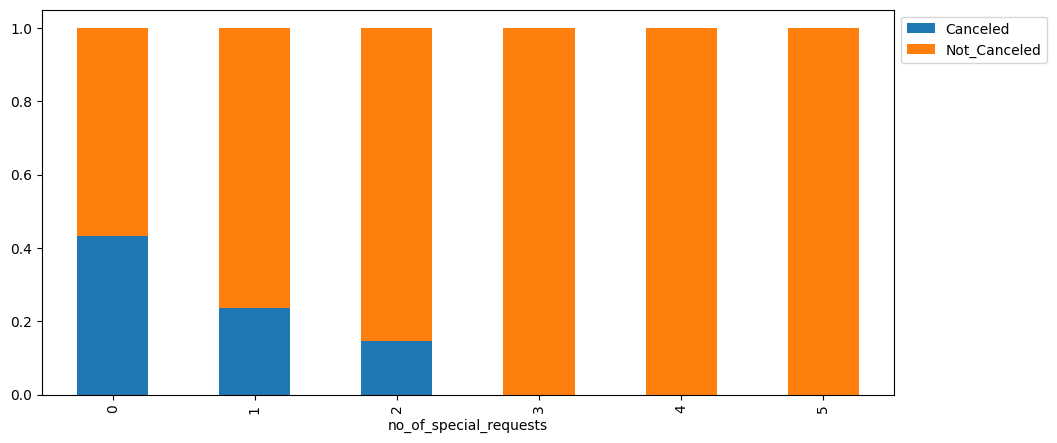

In [378]:
stacked_barplot(data, "no_of_special_requests", "booking_status")

* Guests with no special_requests had the highest rate of cancellation followed by guests with 1 special_requests.
* Guests with 3 or more special requests did not cancel their booking.
* Therefore, the number of special requests is an important factor in predicting whether a guest will cancel their booking or not.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

### Outlier detection and treatment

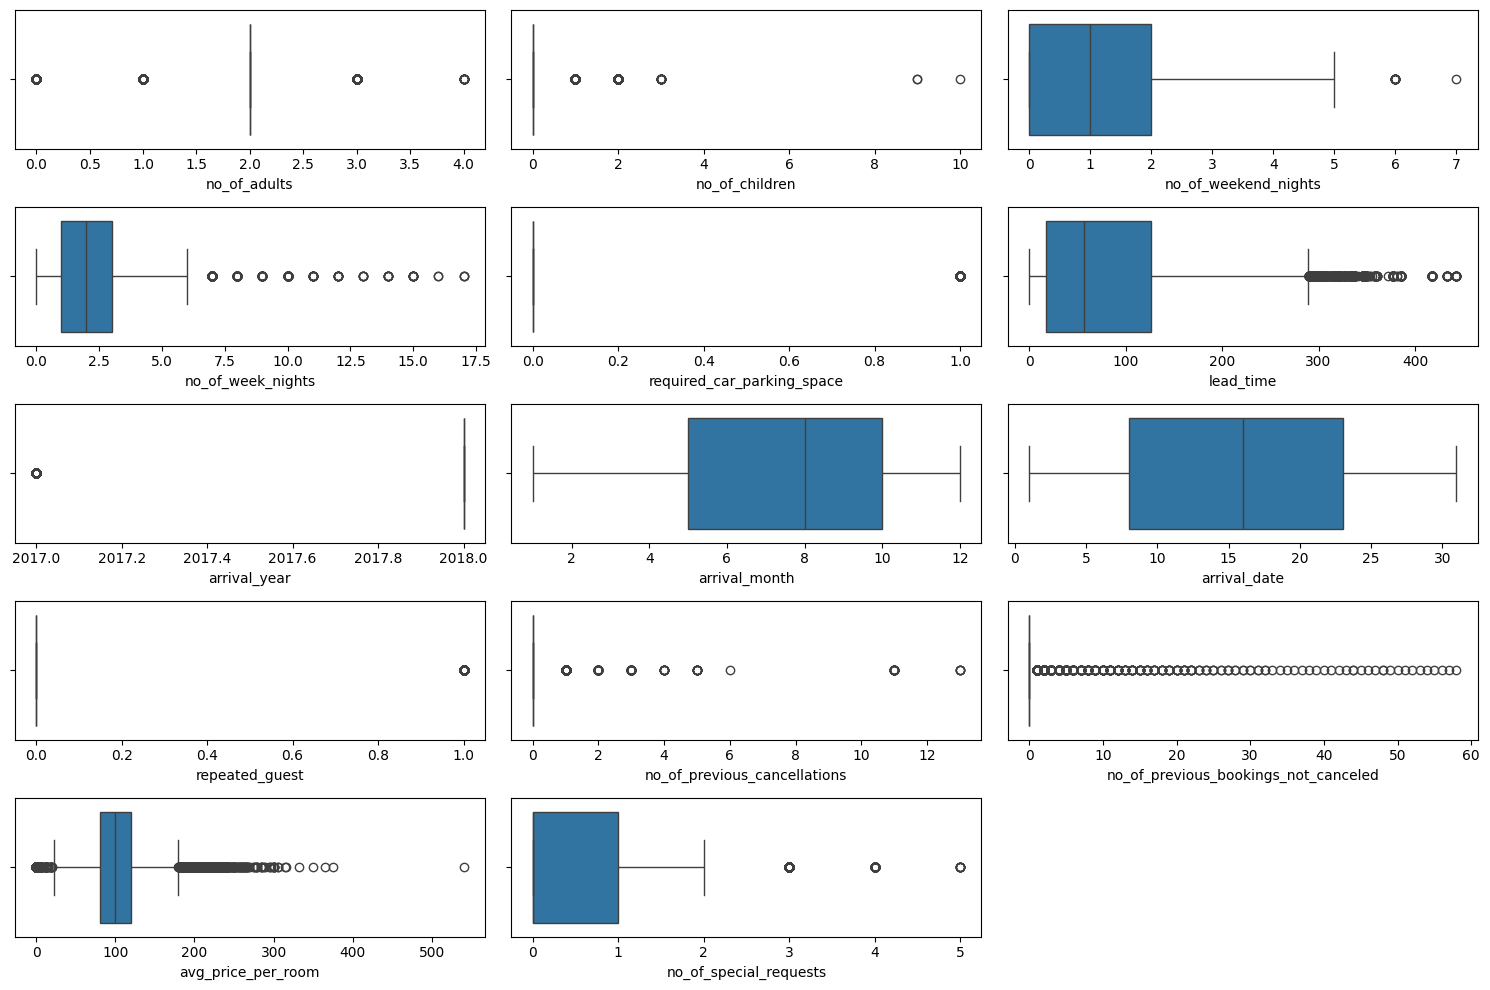

In [379]:
# outlier detection using boxplot
num_cols = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.boxplot(data=data, x=variable)
    plt.tight_layout()
plt.show()

- There are quite a few outliers in the data.
- However, we will not treat them as they are proper values.

### Replacing categorical values into numerical values

In order to perform a logistic regression, we will convert the categorical values for booking_status into numerical values.

In [380]:
# replacing categorical values into numerical values in the booking_status column
data["booking_status"] = data["booking_status"].replace({"Not_Canceled": 0, "Canceled": 1})

Let's look at the distribution of target variable

In [381]:
data["booking_status"].value_counts()

,count
booking_status,
0,24390
1,11885


In [382]:
data["booking_status"].value_counts(normalize=True)

,proportion
booking_status,
0,0.67236
1,0.32764


* The percentage of canceled booking is 33% of the total bookings.

### Preparing data for modeling

- We want to predict the booking status.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.
- We will build a Logistic Regression model using the train data and then check its performance.

In [383]:
X = data.drop(["booking_status"], axis=1)
y = data["booking_status"]

# adding a constant to X variable
X = add_constant(X)

# creating dummies
X = pd.get_dummies(X, drop_first=True)


In [384]:
X.head()

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,1.00000,2,0,1,2,0,224,2017,10,2,0,0,0,65.00000,0,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1.00000,2,0,2,3,0,5,2018,11,6,0,0,0,106.68000,1,False,False,True,False,False,False,False,False,False,False,False,False,True
2,1.00000,1,0,2,1,0,1,2018,2,28,0,0,0,60.00000,0,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1.00000,2,0,0,2,0,211,2018,5,20,0,0,0,100.00000,0,False,False,False,False,False,False,False,False,False,False,False,False,True
4,1.00000,2,0,1,1,0,48,2018,4,11,0,0,0,94.50000,0,False,False,True,False,False,False,False,False,False,False,False,False,True


In [385]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,1.00000,2.00000,0.00000,1.00000,2.00000,0.00000,224.00000,2017.00000,10.00000,2.00000,0.00000,0.00000,0.00000,65.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000
1,1.00000,2.00000,0.00000,2.00000,3.00000,0.00000,5.00000,2018.00000,11.00000,6.00000,0.00000,0.00000,0.00000,106.68000,1.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000
2,1.00000,1.00000,0.00000,2.00000,1.00000,0.00000,1.00000,2018.00000,2.00000,28.00000,0.00000,0.00000,0.00000,60.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000
3,1.00000,2.00000,0.00000,0.00000,2.00000,0.00000,211.00000,2018.00000,5.00000,20.00000,0.00000,0.00000,0.00000,100.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000
4,1.00000,2.00000,0.00000,1.00000,1.00000,0.00000,48.00000,2018.00000,4.00000,11.00000,0.00000,0.00000,0.00000,94.50000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000


### Splitting data into train and test

In [386]:
# splitting data in 70:30 ratio for train to test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

## EDA

- It is a good idea to explore the data once again after manipulating it.

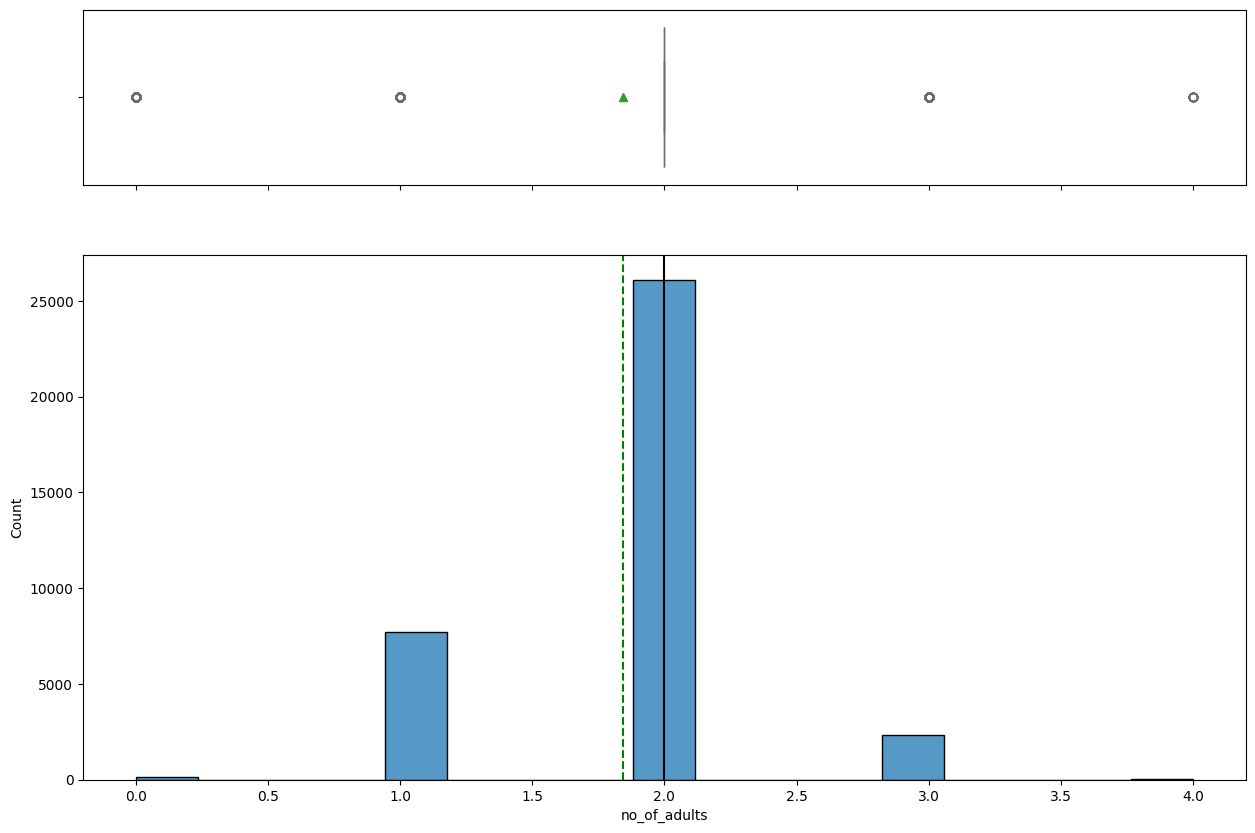

In [387]:
# let's run the functions for visualizing the data one more time
histogram_boxplot(data, "no_of_adults")

* The distribution for no_of_adults is highly concentrated on median with outliers on both ends of the distribution.
* The median value is 2.

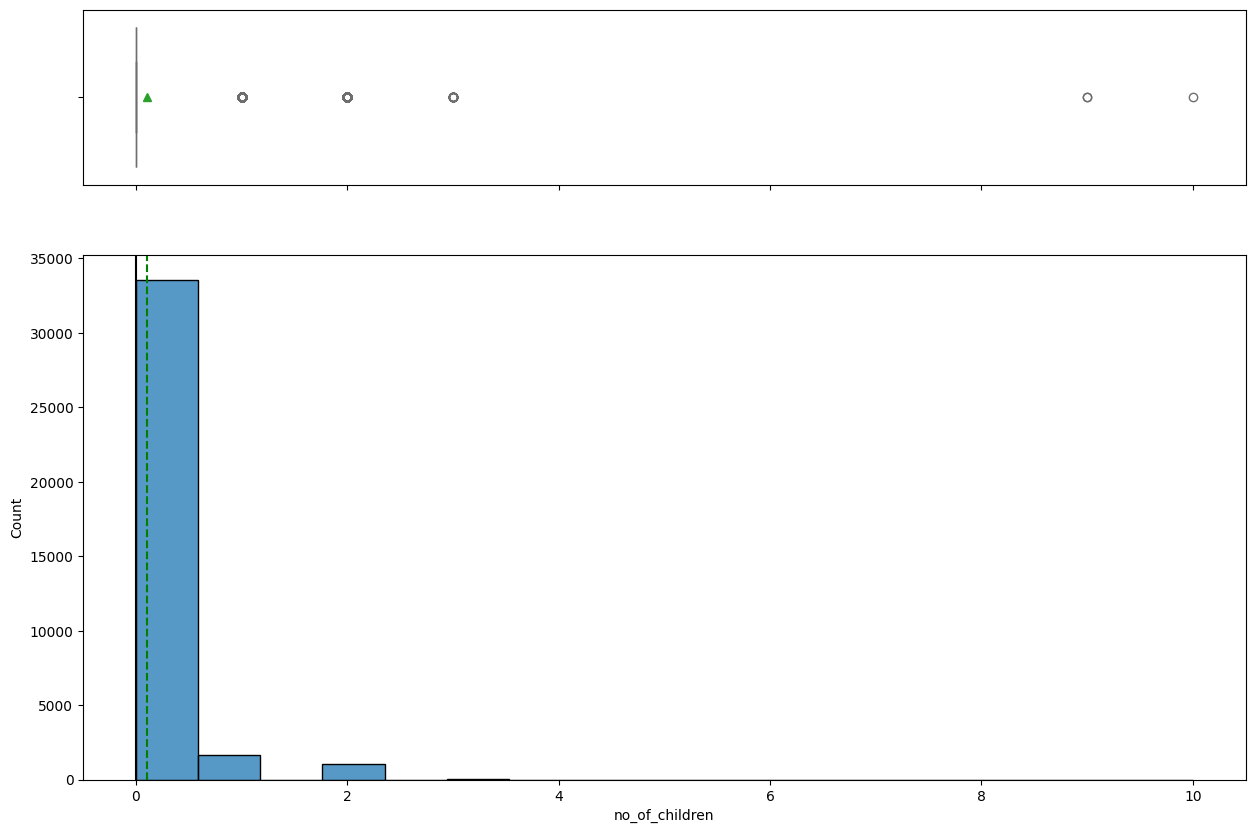

In [388]:
histogram_boxplot(data, "no_of_children")

* The distribution for no_of_children is slightly right skewed and highly concentrated on median with outliers on the right side of the distribution.
* The median value is 0.

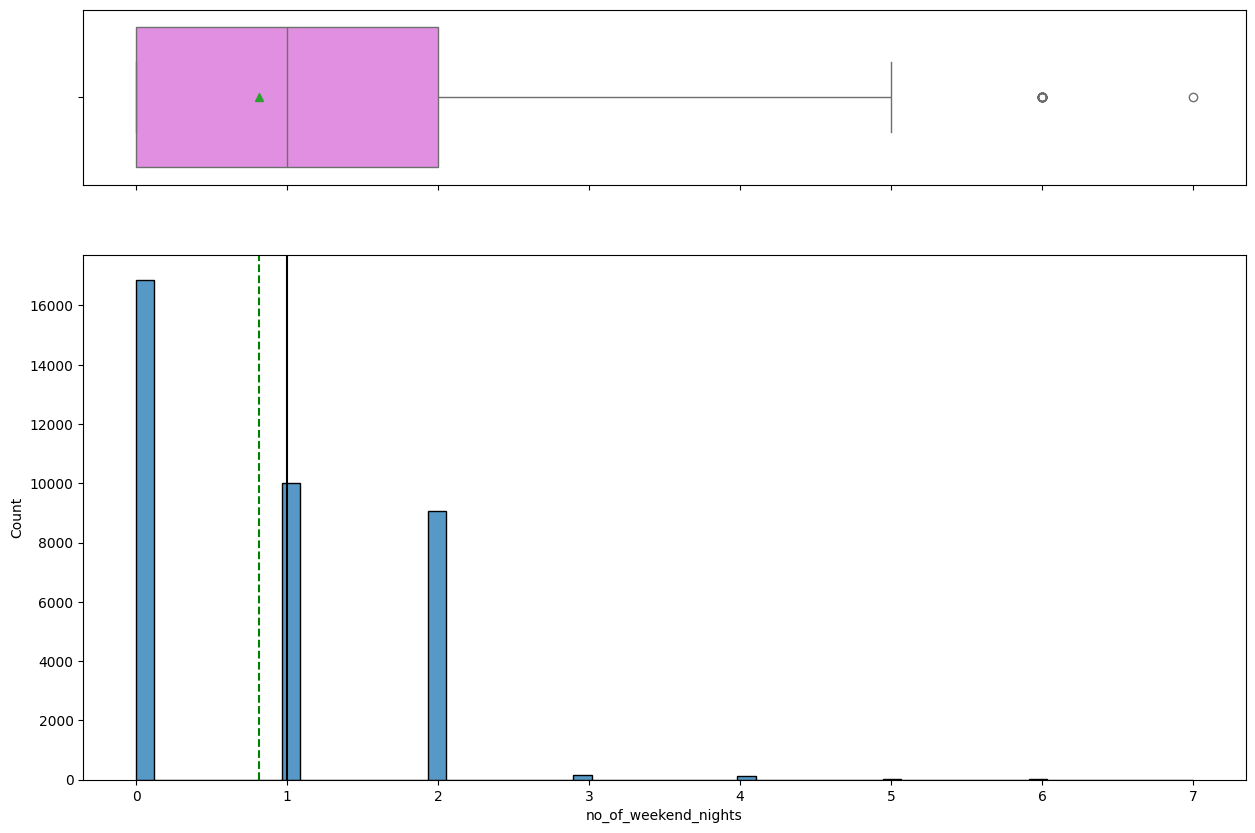

In [389]:
histogram_boxplot(data, "no_of_weekend_nights")

* The distribution for the no_of_weekend_nights is slightly left skewed, with the median of 1.
* There are outliers above the maximum value.

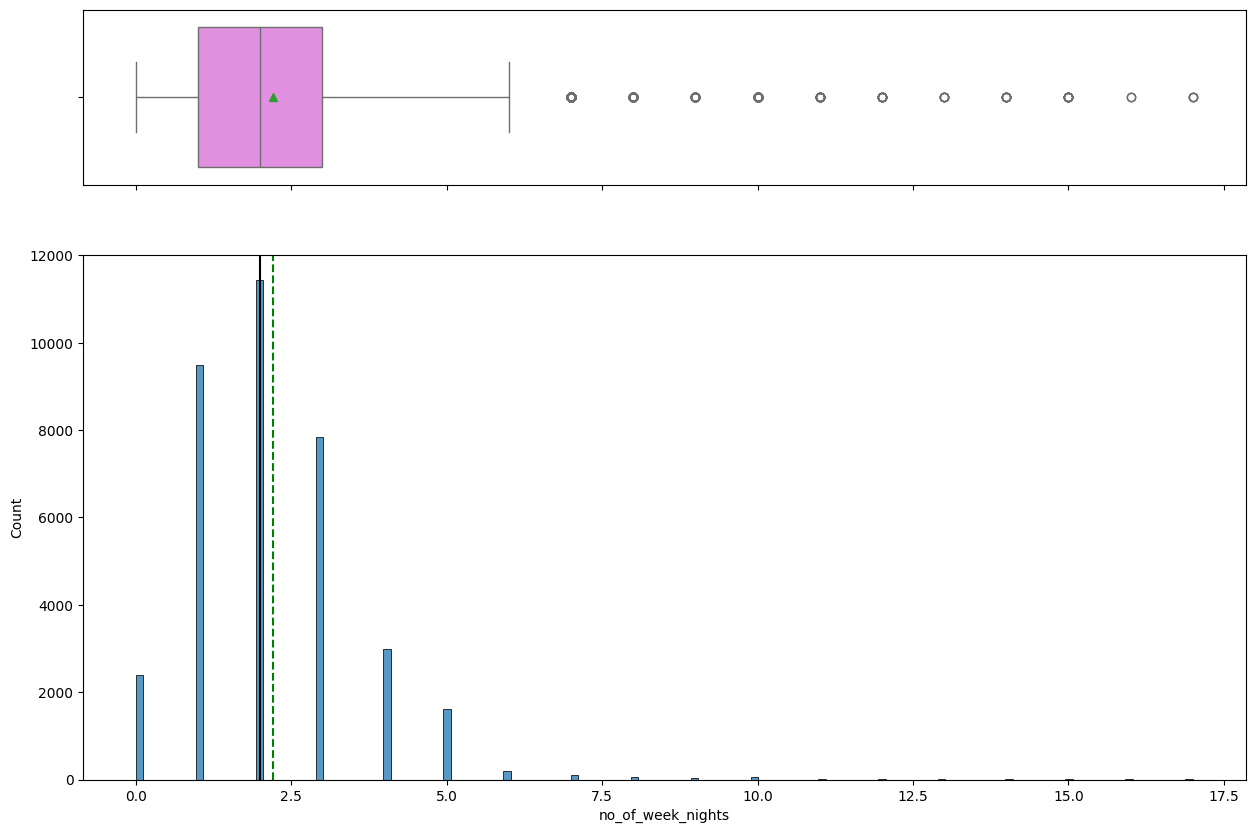

In [390]:
histogram_boxplot(data, "no_of_week_nights")

* The distribution for the no_of_week_nights is slightly right skewed, with the median of 2.
* There are outliers above the maximum value.

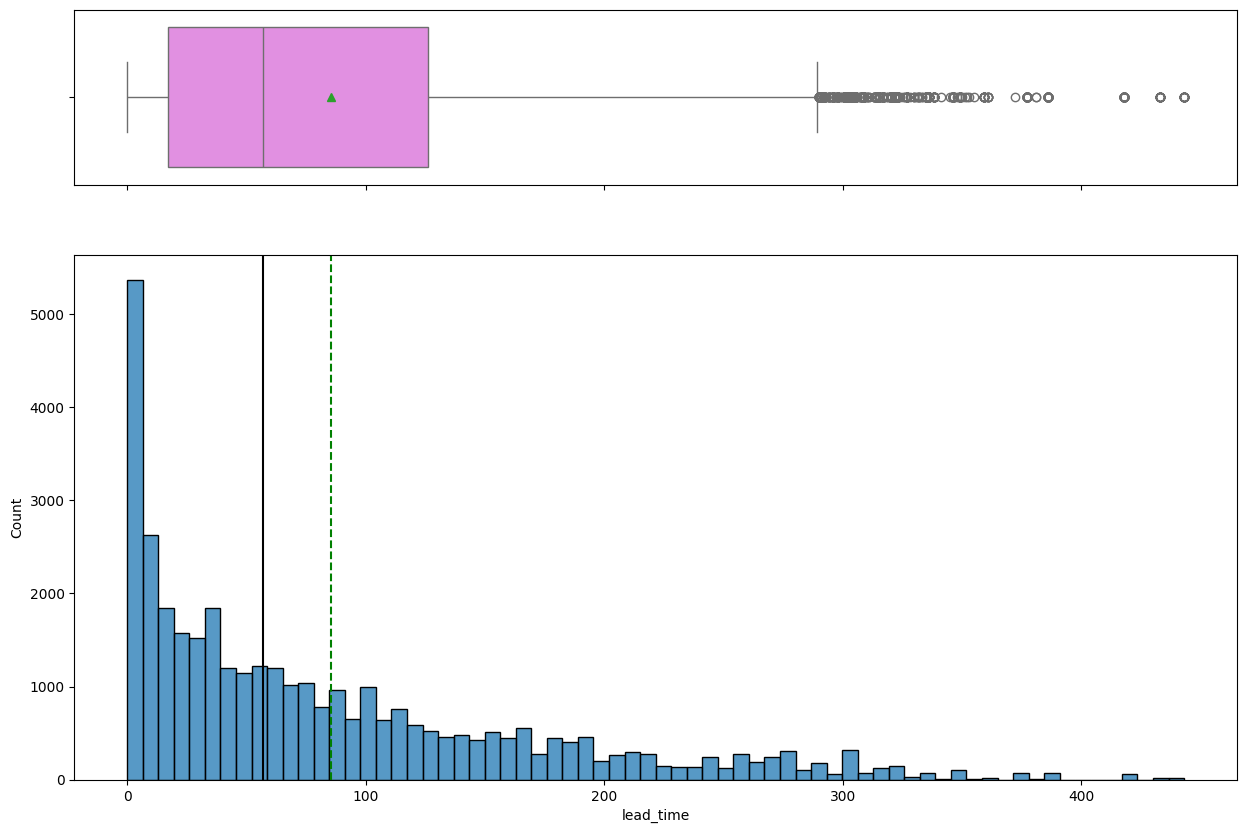

In [391]:
histogram_boxplot(data, "lead_time")

* The distribution for the lead_time is right skewed.
* There are outliers above the maximum value.

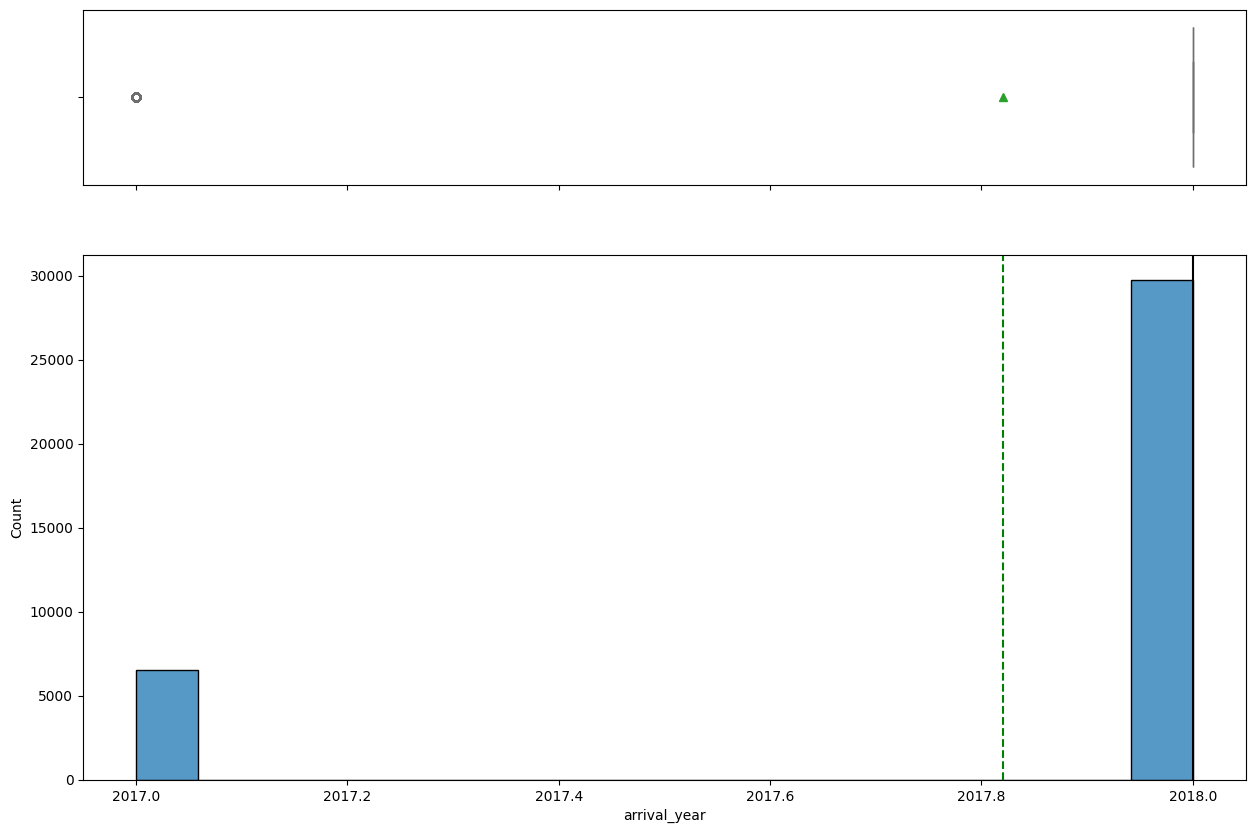

In [392]:
histogram_boxplot(data, "arrival_year")

* The distribution for the arrival_year is left skewed, with the median of 2018.
* There are outliers below the minimum value.

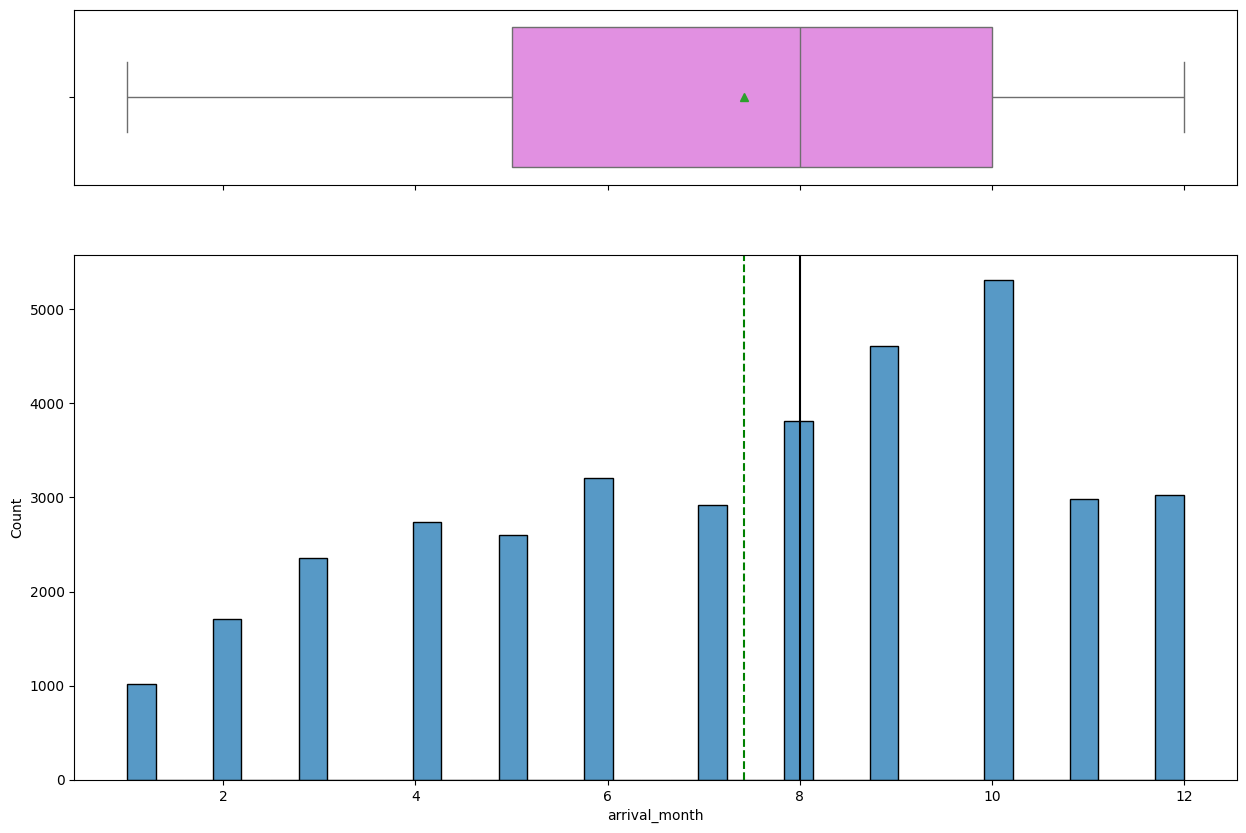

In [393]:
histogram_boxplot(data, "arrival_month")

* The distribution for the arrival_month is slightly left skewed, with the median of 8.
* August, Septempter, and October are the busiest months for the hotel.

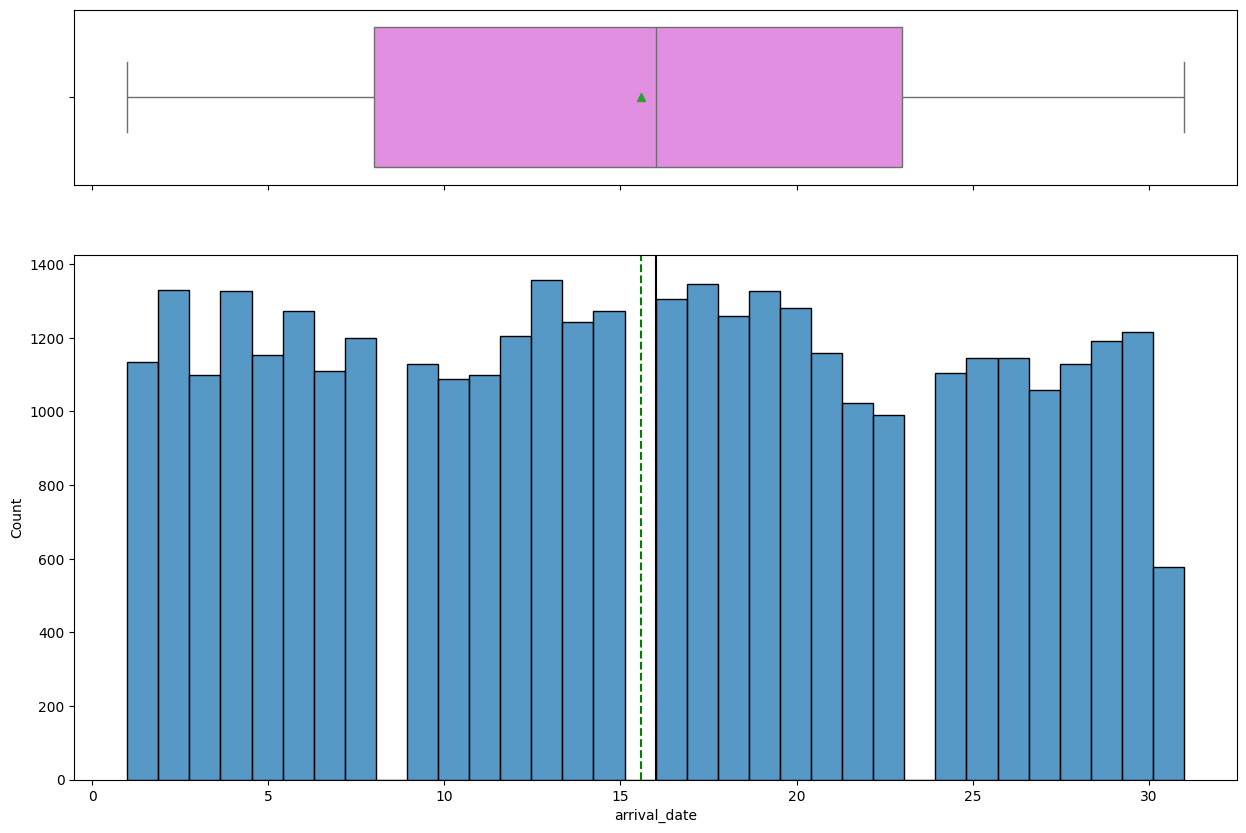

In [394]:
histogram_boxplot(data, "arrival_date")

* The arrival_date is almost uniformly distributed, with the median of 16.
* The arrival_date of 31 is smaller than the other dates because only 7 out of 12 months have 31 days.

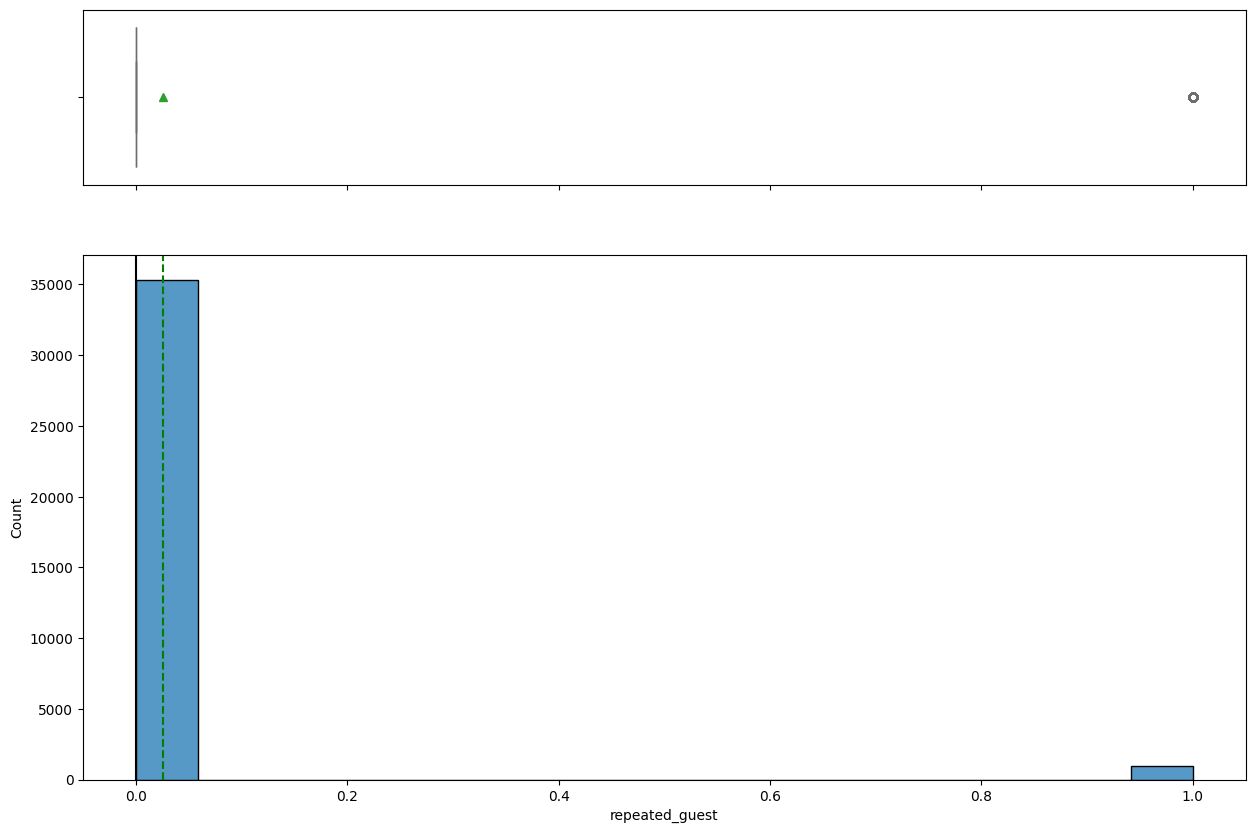

In [395]:
histogram_boxplot(data, "repeated_guest")

* The distribution for the repeated_guest is highly concentrated around the median of 0.

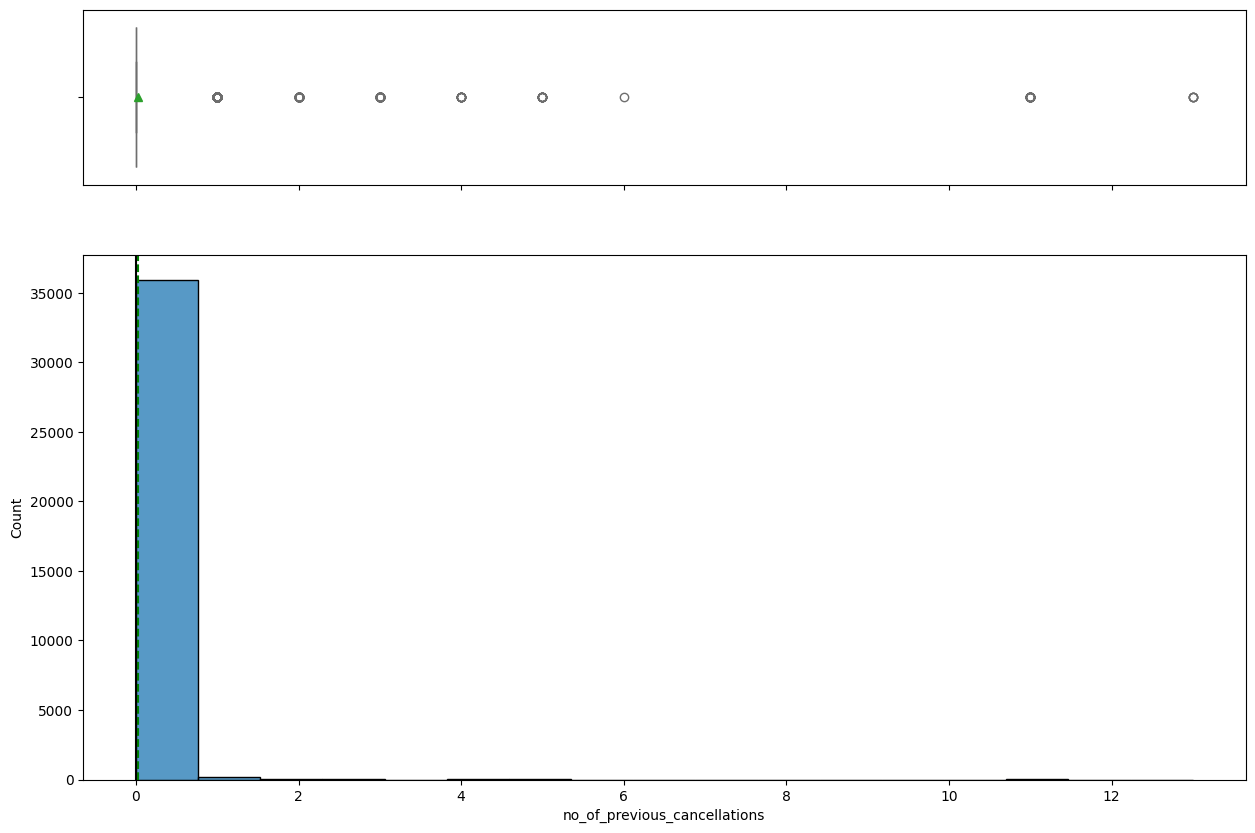

In [396]:
histogram_boxplot(data, "no_of_previous_cancellations")

* The distribution for the no_of_previous_cancellations is highly concentrated around the median of 0.
* There are outliers above the maximum value.

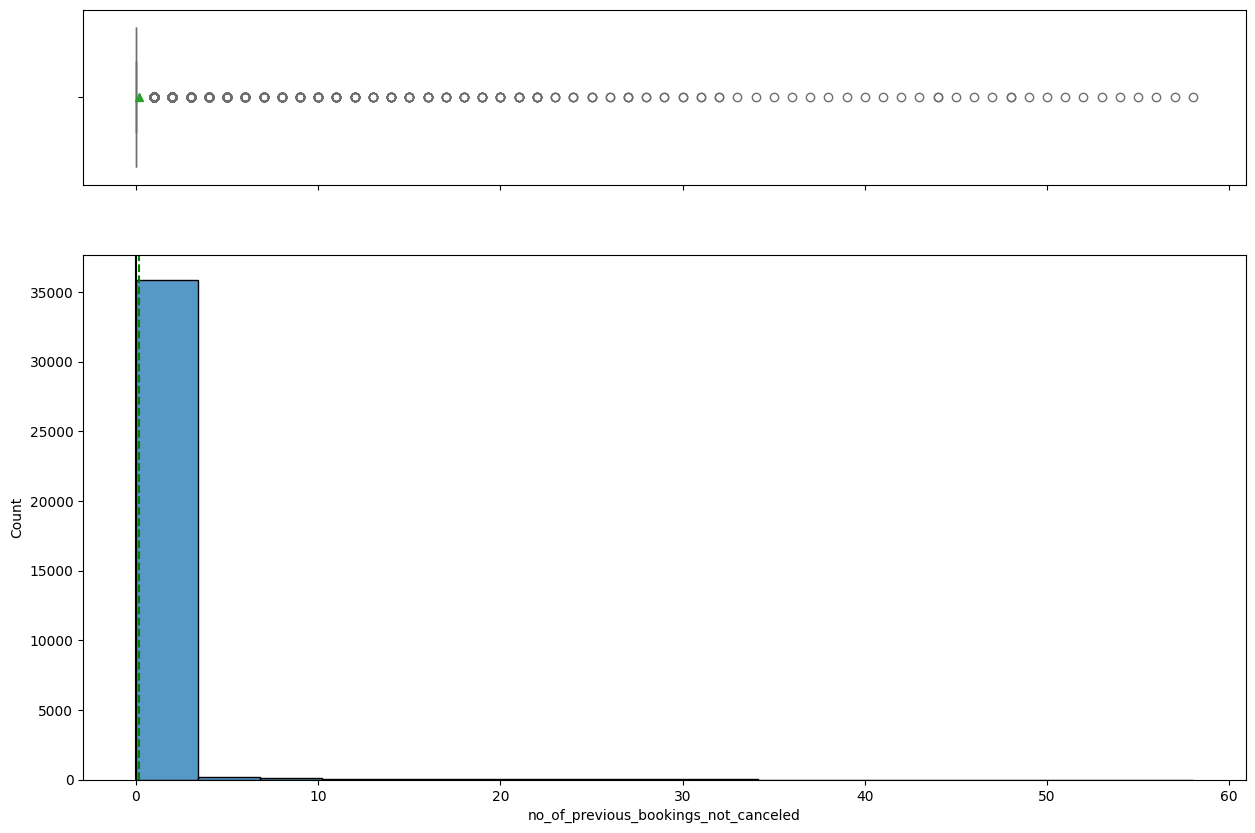

In [397]:
histogram_boxplot(data, "no_of_previous_bookings_not_canceled")

* The distribution for the no_of_previous_bookings_not_canceled is highly concentrated around the median of 0.
* There are outliers above the maximum value.

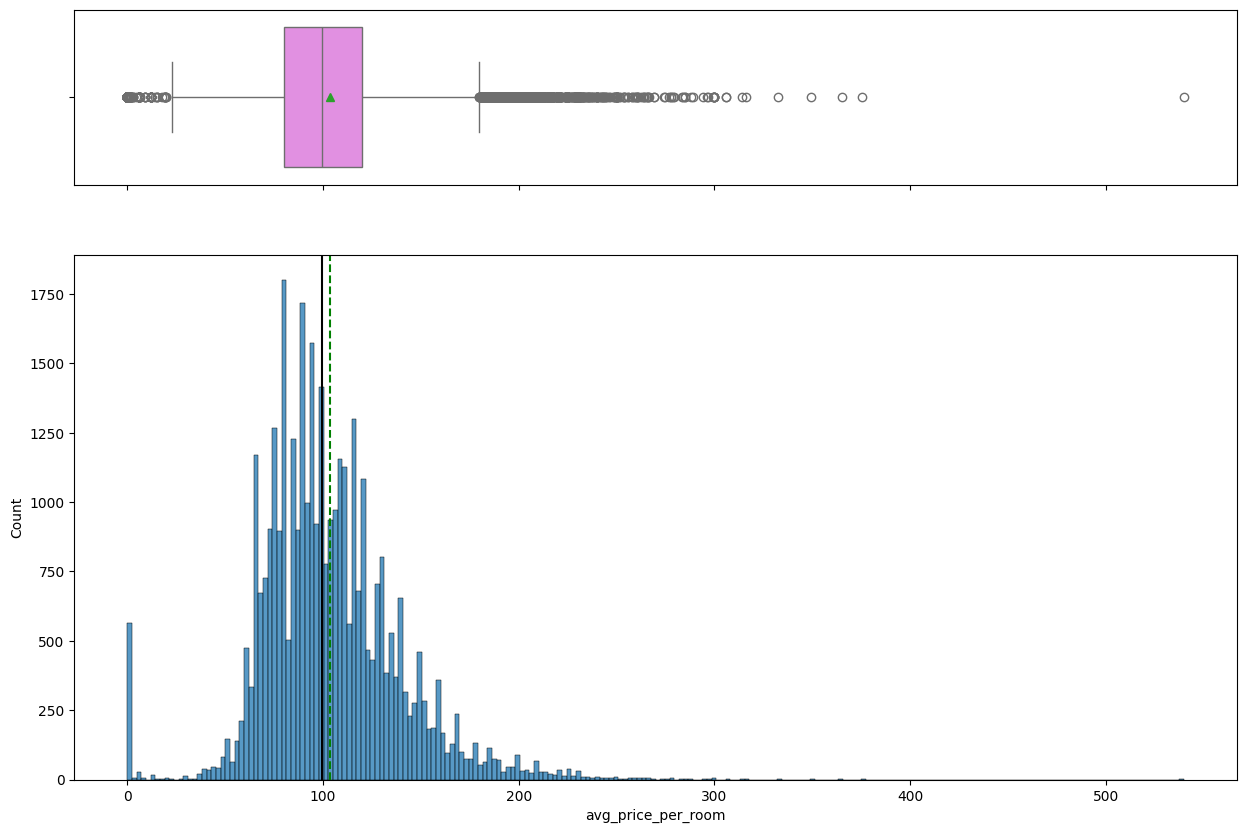

In [398]:
histogram_boxplot(data, "avg_price_per_room")

* The distribution for the avg_price_per_room is slightly right skewed.
* There are outliers on both ends of the distribution.

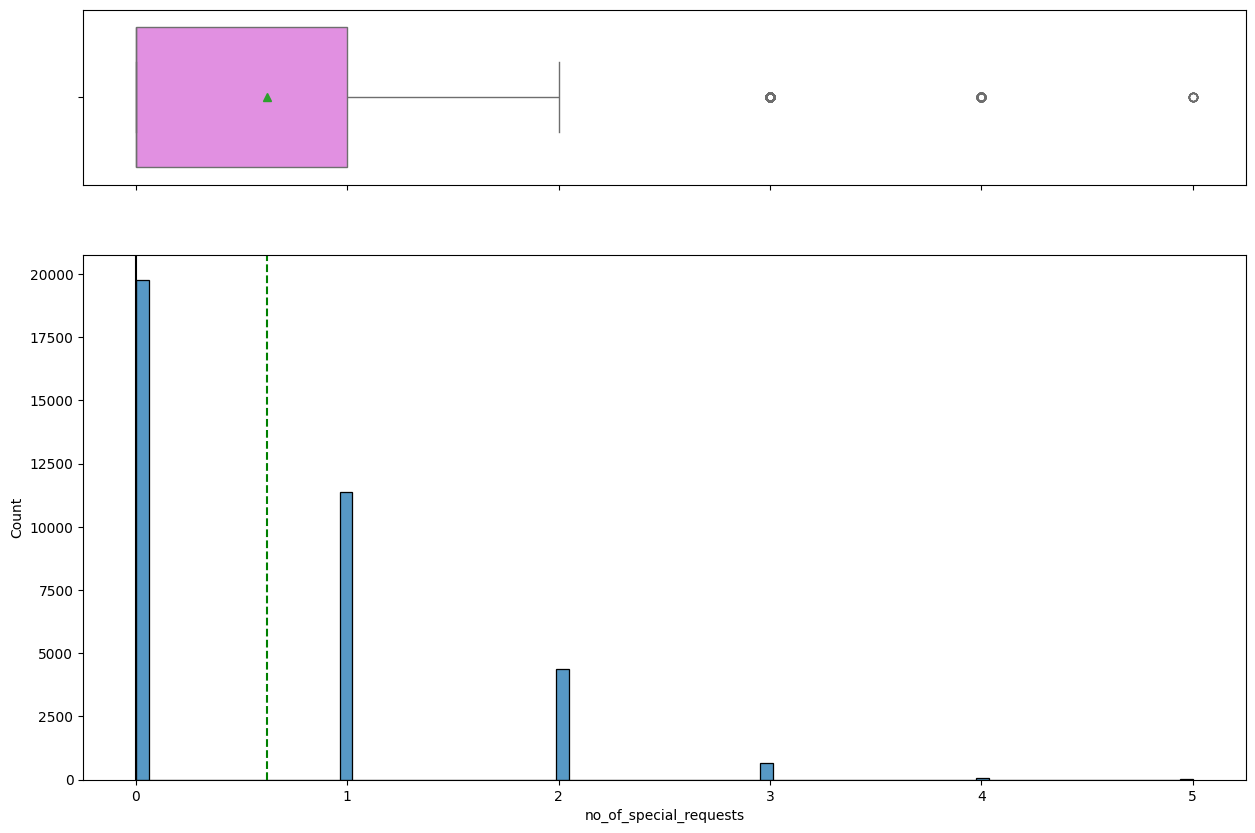

In [399]:
histogram_boxplot(data, "no_of_special_requests")

* The distribution for the no_of_special_guests is right skewed, with the median of 0.
* There are outliers above the maximum value.

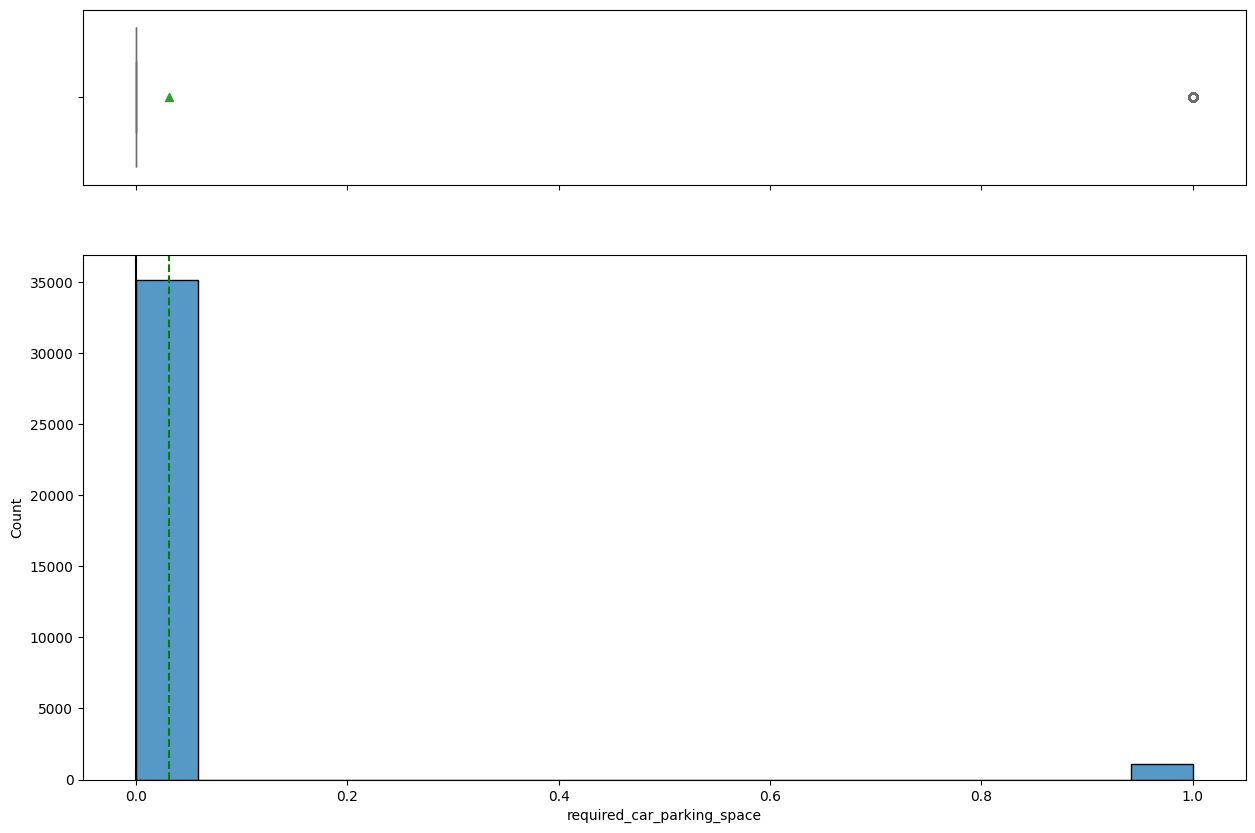

In [400]:
histogram_boxplot(data, "required_car_parking_space")

-	The distribution for the required_car_parking_space is slightly right skewed and highly concentrated around the median of 0.
-	There are outliers above the maximum value.

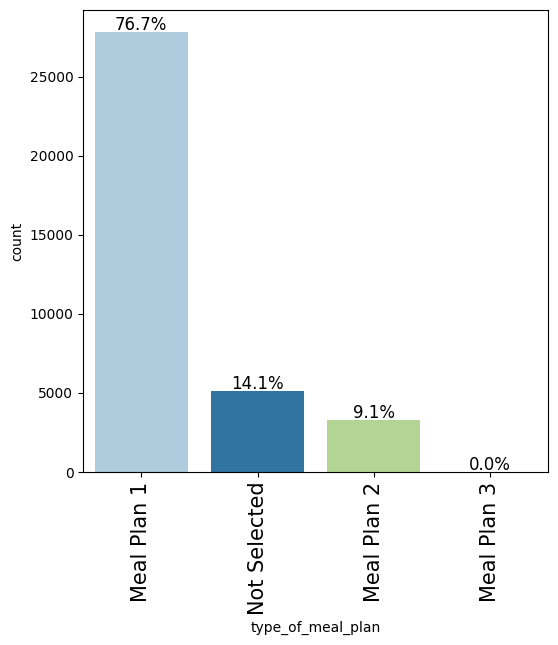

In [401]:
labeled_barplot(data, "type_of_meal_plan", perc=True)

* Meal Plan 1 has the highest percentage of the total meal plan types at 76.7%.

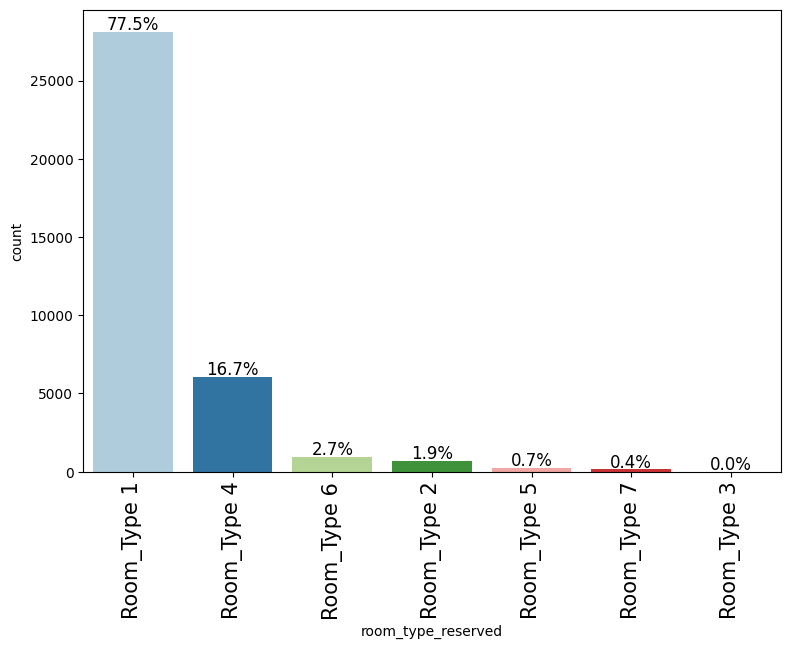

In [402]:
labeled_barplot(data, "room_type_reserved", perc=True)

* Room_Type_1 has the highest percentage of the total room types at 77.5%.

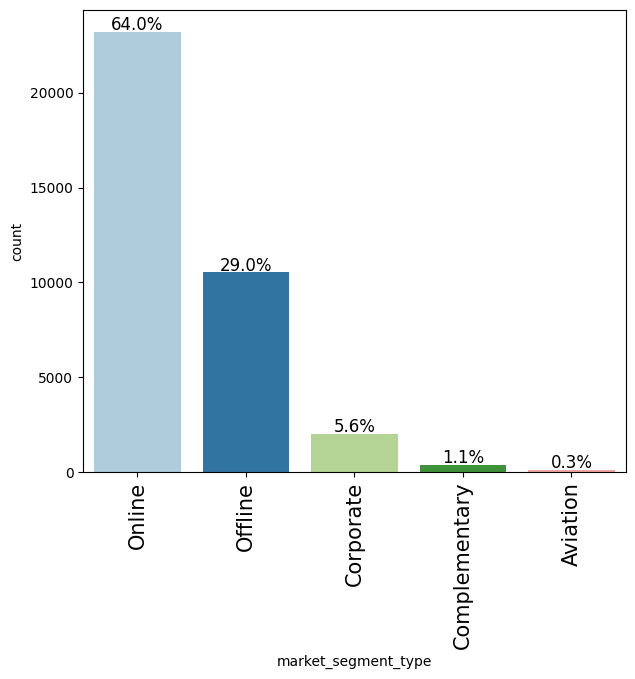

In [403]:
labeled_barplot(data, "market_segment_type", perc=True)

* Online has the highest percentage of the total market segment types at 64.0%, followed by Offline at 29.0%.

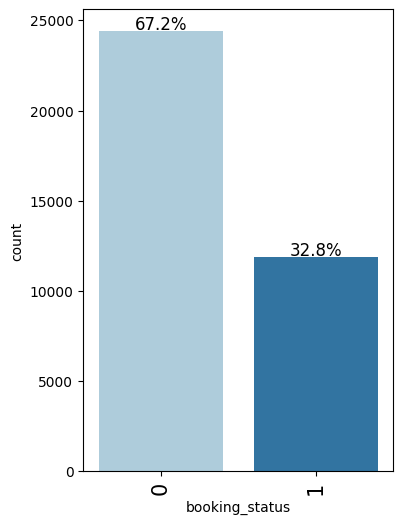

In [404]:
labeled_barplot(data, "booking_status", perc=True)

* Almost one-third (or 32.8%) of the guests canceled their booking, which presents a huge challenge for the hotel management.
* In order to perform a logistic regression analysis we will replace the categorical values with numeric values for the booking_status.

## Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

### Test for Multicollinearity

* There are different ways of detecting (or testing) multicollinearity. One such way is by using the Variance Inflation Factor, or VIF.

* **Variance  Inflation Factor (VIF)**:  Variance inflation factors measure the inflation in the variances of the regression parameter estimates due to collinearities that exist among the predictors. It is a measure of how much the variance of the estimated regression coefficient $\beta_k$ is "inflated" by the existence of correlation among the predictor variables in the model.
    - If VIF is 1, then there is no correlation among the $k$th predictor and the remaining predictor variables, and hence, the variance of $\beta_k$ is not inflated at all.

* **General Rule of thumb**:
    - If VIF is between 1 and 5, then there is low multicollinearity.
    - If VIF is between 5 and 10, we say there is moderate multicollinearity.
    - If VIF is exceeding 10, it shows signs of high multicollinearity.

Let's define a function to check VIF.

In [405]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# defining a function to check VIF
def checking_vif(predictors):
    """
    Function to check VIF for multicollinearity
    """
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [406]:
checking_vif(X_train)

,feature,VIF
0,const,39595445.81095
1,no_of_adults,1.34506
2,no_of_children,2.00721
3,no_of_weekend_nights,1.06725
4,no_of_week_nights,1.09437
5,required_car_parking_space,1.03494
6,lead_time,1.40192
7,arrival_year,1.43326
8,arrival_month,1.27740
9,arrival_date,1.00763


* There are no columns with very high VIF values, except for dummy variables and the constant (intercept).
* We will ignore the VIF values for dummy variables and the constant (intercept).
* Therefore, we do not need to drop any columns for multicollinearity.

## Building a Logistic Regression model

### Fitting Logistic Regression model

In [407]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train)
lg = logit.fit(max_iter=1000)

         Current function value: 0.422351
         Iterations: 35


In [408]:
# let's print the logistic regression summary
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25364
Method:                           MLE   Df Model:                           27
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3322
Time:                        23:44:54   Log-Likelihood:                -10724.
converged:                      False   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -886.9563    121.332     -7.310      0.000   -1124.762    -649.150
no_of_adults                             0.0333      

* The coefficients of the logistic regression model are in terms of log(odd).
* P>|z|: The interpretation of p-values is similar to that in Linear Regression.

## Model performance evaluation

In [409]:
# predicting on training set
# default threshold is 0.5. If predicted probability is greater than 0.5, the observation will be classified as 1.
pred_train = lg.predict(X_train) > 0.5
pred_train = np.round(pred_train)

Let's see the confusion matrix on training set

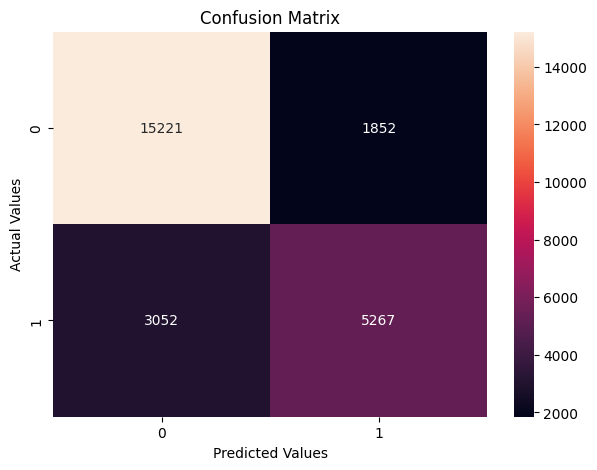

In [410]:
cm = confusion_matrix(y_train, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")
plt.show()

#### The confusion matrix

* True Positives (TP):  A guest canceled his/her booking and the model predicted the person would canceled his/her booking.
* True Negatives (TN): A guest didn't cancel his/her booking and the model predicted the person wouldn't cancel his/her booking.
* False Positives (FP): The model predicted the guest would cancel his/her booking but the person didn't cancel his/her booking.
* False Negatives (FN): The model predicted the guest wouldn't cancel his/her booking but the person canceled his/her booking.

Let's check the accuracy of the model.

In [411]:
# checking the accuracy on training set
print("Accuracy on training set:", accuracy_score(y_train, pred_train))

Accuracy on training set: 0.8068683049779458


* The model seems to be performing well on the training set.

Since there is no multicollinearity present in the dataset, the values of coefficients and p-values are reliable. Let's remove the insignificant variables (p-value > 0.05) from data.

### Removing insignificant variables (p-value > 0.05)

In [412]:
# summary of initial logistic regression model
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25364
Method:                           MLE   Df Model:                           27
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3322
Time:                        23:44:55   Log-Likelihood:                -10724.
converged:                      False   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -886.9563    121.332     -7.310      0.000   -1124.762    -649.150
no_of_adults                             0.0333      

**Dropping market_segment_type_Complementary as it has the highest p-value**

In [413]:
X_train1 = X_train.drop("market_segment_type_Complementary", axis=1)

In [414]:
# fitting the model on training set
logit1 = sm.Logit(y_train, X_train1)
lg1 = logit1.fit(max_iter=1000)

pred_train1 = lg1.predict(X_train1) > 0.5
pred_train1 = np.round(pred_train1)

print("Accuracy on training set:", accuracy_score(y_train, pred_train1))

Optimization terminated successfully.
         Current function value: 0.422630
         Iterations 16
Accuracy on training set: 0.8063563327032136


* There is no significant change in the model performance as compared to initial model.

In [415]:
# checking summary of the model
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25365
Method:                           MLE   Df Model:                           26
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3318
Time:                        23:44:55   Log-Likelihood:                -10731.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -889.3698    121.210     -7.337      0.000   -1126.936    -651.803
no_of_adults                             0.0274      

**Dropping room_type_reserved_Room_Type 3 with the highest p-value**

In [416]:
X_train2 = X_train1.drop("room_type_reserved_Room_Type 3", axis=1)

In [417]:
# fitting the model on training set
logit2 = sm.Logit(y_train, X_train2)
lg2 = logit2.fit(max_iter=1000)

pred_train2 = lg2.predict(X_train2) > 0.5
pred_train2 = np.round(pred_train2)

print("Accuracy on training set:", accuracy_score(y_train, pred_train2))

Optimization terminated successfully.
         Current function value: 0.422635
         Iterations 16
Accuracy on training set: 0.8063957151858853


* There is no significant change in the model performance as compared to initial model.

In [418]:
# checking summary of the model
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25366
Method:                           MLE   Df Model:                           25
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3318
Time:                        23:44:56   Log-Likelihood:                -10732.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -889.0510    121.207     -7.335      0.000   -1126.612    -651.490
no_of_adults                             0.0274      

**Dropping no_of_adults with the highest p-value**

In [419]:
X_train3 = X_train2.drop("no_of_adults", axis=1)

In [420]:
# fitting the model on training set
logit3 = sm.Logit(y_train, X_train3)
lg3 = logit3.fit(max_iter=1000)

pred_train3 = lg3.predict(X_train3) > 0.5
pred_train3 = np.round(pred_train3)

print("Accuracy on training set:", accuracy_score(y_train, pred_train3))

Optimization terminated successfully.
         Current function value: 0.422646
         Iterations 15
Accuracy on training set: 0.8065926275992439


* There is no significant change in the model performance as compared to initial model.

In [421]:
## checking summary of the model
print(lg3.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25367
Method:                           MLE   Df Model:                           24
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3318
Time:                        23:44:56   Log-Likelihood:                -10732.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -885.9115    121.142     -7.313      0.000   -1123.346    -648.477
no_of_children                           0.0737      

**Dropping type_of_meal_plan_Meal Plan 3 with the highest p-value**

In [422]:
X_train4 = X_train3.drop("type_of_meal_plan_Meal Plan 3", axis=1)

In [423]:
# fitting the model on training set
logit4 = sm.Logit(y_train, X_train4)
lg4 = logit4.fit(max_iter=1000)

pred_train4 = lg4.predict(X_train4) > 0.5
pred_train4 = np.round(pred_train4)

print("Accuracy on training set:", accuracy_score(y_train, pred_train4))

Optimization terminated successfully.
         Current function value: 0.422686
         Iterations 16
Accuracy on training set: 0.8065532451165721


* There is no significant change in the model performance as compared to initial model.

In [424]:
## checking summary of the model
print(lg4.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25368
Method:                           MLE   Df Model:                           23
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3317
Time:                        23:44:56   Log-Likelihood:                -10733.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -881.6953    121.080     -7.282      0.000   -1119.008    -644.382
no_of_children                           0.0734      

**Dropping no_of_children with the highest p-value**

In [425]:
X_train5 = X_train4.drop("no_of_children", axis=1)

In [426]:
# fitting the model on training set
logit5 = sm.Logit(y_train, X_train5)
lg5 = logit5.fit(max_iter=1000)

pred_train5 = lg5.predict(X_train5) > 0.5
pred_train5 = np.round(pred_train5)

print("Accuracy on training set:", accuracy_score(y_train, pred_train5))

Optimization terminated successfully.
         Current function value: 0.422715
         Iterations 16
Accuracy on training set: 0.8066713925645873


* There is no significant change in the model performance as compared to initial model.

In [427]:
## checking summary of the model
print(lg5.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25369
Method:                           MLE   Df Model:                           22
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3317
Time:                        23:44:57   Log-Likelihood:                -10734.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -885.5409    121.030     -7.317      0.000   -1122.755    -648.326
no_of_weekend_nights                     0.1491      

**Dropping no_of_previous_bookings_not_canceled with the highest p-value**

In [428]:
X_train6 = X_train5.drop("no_of_previous_bookings_not_canceled", axis=1)

In [429]:
# fitting the model on training set
logit6 = sm.Logit(y_train, X_train6)
lg6 = logit6.fit(max_iter=1000)

pred_train6 = lg6.predict(X_train6) > 0.5
pred_train6 = np.round(pred_train6)

print("Accuracy on training set:", accuracy_score(y_train, pred_train6))

Optimization terminated successfully.
         Current function value: 0.422882
         Iterations 11
Accuracy on training set: 0.806710775047259


* There is no significant change in the model performance as compared to initial model.

In [430]:
## checking summary of the model
print(lg6.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25370
Method:                           MLE   Df Model:                           21
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3314
Time:                        23:44:57   Log-Likelihood:                -10738.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -881.3654    121.049     -7.281      0.000   -1118.617    -644.114
no_of_weekend_nights               0.1491      0.020      7.529      0.

**Dropping arrival_date with the highest p-value**

In [431]:
X_train7 = X_train6.drop("arrival_date", axis=1)

In [432]:
# fitting the model on training set
logit7 = sm.Logit(y_train, X_train7)
lg7 = logit7.fit(max_iter=1000)

pred_train7 = lg7.predict(X_train7) > 0.5
pred_train7 = np.round(pred_train7)

print("Accuracy on training set:", accuracy_score(y_train, pred_train7))

Optimization terminated successfully.
         Current function value: 0.422928
         Iterations 11
Accuracy on training set: 0.8061988027725268


* There is no significant change in the model performance as compared to initial model.

In [433]:
## checking summary of the model
print(lg7.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25371
Method:                           MLE   Df Model:                           20
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3313
Time:                        23:44:58   Log-Likelihood:                -10739.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -881.8023    121.089     -7.282      0.000   -1119.133    -644.472
no_of_weekend_nights               0.1499      0.020      7.568      0.

**Dropping market_segment_type_Online with the highest p-value**

In [434]:
X_train8 = X_train7.drop("market_segment_type_Online", axis=1)

In [435]:
# fitting the model on training set
logit8 = sm.Logit(y_train, X_train8)
lg8 = logit8.fit(max_iter=1000)

pred_train8 = lg8.predict(X_train8) > 0.5
pred_train8 = np.round(pred_train8)

print("Accuracy on training set:", accuracy_score(y_train, pred_train8))

Optimization terminated successfully.
         Current function value: 0.422990
         Iterations 12
Accuracy on training set: 0.8065926275992439


* There is no significant change in the model performance as compared to initial model.

In [436]:
## checking summary of the model
print(lg8.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25372
Method:                           MLE   Df Model:                           19
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.3312
Time:                        23:44:58   Log-Likelihood:                -10741.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -869.8889    120.911     -7.194      0.000   -1106.870    -632.908
no_of_weekend_nights               0.1498      0.020      7.568      0.

* Now all the columns left are significant predictors, let's check the model performance and make interpretations.

## Final Model Summary

### Coefficient interpretations

* Coefficient of the variables are positive and negative. An increase in positive coefficients will lead to increase in chances of a guest cancelling his/her booking whereas a decrease in negative coefficients will lead to decrease in chances of a guest cancelling his/her booking.

### Converting coefficients to odds
* The coefficients of the logistic regression model are in terms of log(odd). To find the odds we have to take the exponential of the coefficients.
* Therefore, odds = exp(b)
* The percentage change in odds is given as odds = (exp(b) - 1) * 100

**Odds from coefficients**

In [437]:
# converting coefficients to odds
odds = np.exp(lg8.params)

# adding the odds to a dataframe
pd.DataFrame(odds, X_train8.columns, columns=["odds"]).T

,const,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Offline
odds,0.00000,1.16163,1.03686,0.19893,1.01601,1.53690,0.95202,0.04620,1.33534,1.01923,0.22639,1.18160,1.23349,0.68837,0.76503,0.50261,0.47622,0.26847,0.41852,0.16991


**Percentage change in odds**

In [438]:
# finding the percentage change
perc_change_odds = (np.exp(lg8.params) - 1) * 100

# adding the percentage change in odds to a dataframe
pd.DataFrame(perc_change_odds, X_train8.columns, columns=["change_odds%"]).T

,const,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Offline
change_odds%,-100.00000,16.16282,3.68572,-80.10671,1.60144,53.69000,-4.79758,-95.37970,33.53397,1.92270,-77.36112,18.15955,23.34870,-31.16329,-23.49673,-49.73868,-52.37831,-73.15301,-58.14827,-83.00891


### Coefficient interpretations
* no_of_weekend_nights: Holding all other features constant, a unit change in no_of_weekend_nights will increase the odds of a person cancelling his/her booking by 1.1616 times or a 16.16% increase in the odds of cancelling his/her booking.
* required_car_parking_space: Holding all other features constant, a unit change in required_car_parking_space will decrease the odds of a person cancelling his/her booking by 0.1989 times or a 80.11% decrease in the odds of cancelling his/her booking.
* arrival_year: Holding all other features constant, a unit change in arrival_year will increase the odds of a person cancelling his/her booking by 1.5369 times or a 53.69% increase in the odds of cancelling his/her booking.
* repeated_guest: Holding all other features constant, a unit change in repeated_guest will decrease the odds of a person cancelling his/her booking by 0.0462 times or a 95.38% decrease in the odds of cancelling his/her booking.
* no_of_previous_cancellations: Holding all other features constant, a unit change in no_of_previous_cancellations will increase the odds of a person cancelling his/her booking by 1.3353 times or a 33.53% increase in the odds of cancelling his/her booking.
* no_of_special_requests: Holding all other features constant, a unit change in no_of_special_requests will decrease the odds of a person cancelling his/her booking by 0.2264 times or a 77.36% decrease in the odds of cancelling his/her booking.
* type_of_meal_plan_Meal Plan 2: Holding all other features constant, a unit change in type_of_meal_plan_Meal Plan 2 will increase the odds of a person cancelling his/her booking by 1.1816 times, compared to Meal Plan 1 or a 18.16% increase in the odds of cancelling his/her booking.
* type_of_meal_plan_Not Selected: Holding all other features constant, a unit change in type_of_meal_plan_Not Selected will increase the odds of a person cancelling his/her booking by 1.2335 times, compared to Meal Plan 1 or a 23.35% increase in the odds of cancelling his/her booking.
* room_type_reserved_Room_Type 2: Holding all other features constant, a unit change in room_type_reserved_Room_Type 2 will decrease the odds of a person cancelling his/her booking by 0.6884 times, compared to Room_Type 1 or a 31.16% decrease in the odds of cancelling his/her booking.
* room_type_reserved_Room_Type 4: Holding all other features constant, a unit change in room_type_reserved_Room_Type 4 will decrease the odds of a person cancelling his/her booking by 0.7653 times, compared to Room_Type 1 or a 23.50% decrease in the odds of cancelling his/her booking.
* room_type_reserved_Room_Type 5: Holding all other features constant, a unit change in room_type_reserved_Room_Type 5 will decrease the odds of a person cancelling his/her booking by 0.5026 times, compared to Room_Type 1 or a 49.74% decrease in the odds of cancelling his/her booking.
* room_type_reserved_Room_Type 6: Holding all other features constant, a unit change in room_type_reserved_Room_Type 6 will decrease the odds of a person cancelling his/her booking by 0.4762 times, compared to Room_Type 1 or a 52.38% decrease in the odds of cancelling his/her booking.
* room_type_reserved_Room_Type 7: Holding all other features constant, a unit change in room_type_reserved_Room_Type 7 will decrease the odds of a person cancelling his/her booking by 0.2688 times, compared to Room_Type 1 or a 73.15% decrease in the odds of cancelling his/her booking.
* market_segment_type_Corporate: Holding all other features constant, a unit change in market_segment_type_Corporate will decrease the odds of a person cancelling his/her booking by 0.4185 times, compared to Complementary or a 58.15% decrease in the odds of cancelling his/her booking.
* market_segment_type_Offline: Holding all other features constant, a unit change in market_segment_type_Offline will decrease the odds of a person cancelling his/her booking by 0.1699 times, compared to Complementary or a 83.01% decrease in the odds of cancelling his/her booking.

### Performance Metrics on the final model - 'lg8'

**Confusion Matrix on training set**

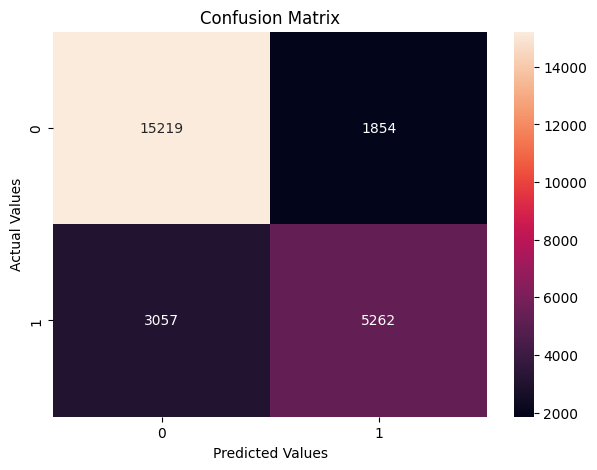

In [439]:
# visualizing confusion matrix on training set
cm = confusion_matrix(y_train, pred_train8)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")
plt.show()

**Accuracy on training set**

In [440]:
print("Accuracy on training set : ", accuracy_score(y_train, pred_train8))

Accuracy on training set :  0.8065926275992439


**ROC-AUC on training set**

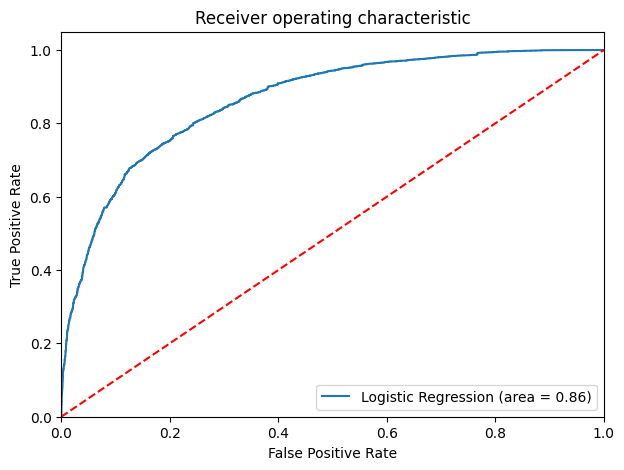

In [441]:
logit_roc_auc_train = roc_auc_score(y_train, lg8.predict(X_train8))
fpr, tpr, thresholds = roc_curve(y_train, lg8.predict(X_train8))
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

* Model is performing well on the training set.

We can now use the model for making predictions on the test data.

In [442]:
# dropping variables from test set as well which were dropped from training set
X_test1 = X_test.drop(["market_segment_type_Complementary", "room_type_reserved_Room_Type 3", "no_of_adults", "type_of_meal_plan_Meal Plan 3", "no_of_children", "no_of_previous_bookings_not_canceled", "arrival_date", "market_segment_type_Online"], axis=1)

In [443]:
pred_test = lg8.predict(X_test1) > 0.5
pred_test = np.round(pred_test)

In [444]:
print("Accuracy on training set:", accuracy_score(y_train, pred_train8))
print("Accuracy on test set:", accuracy_score(y_test, pred_test))

Accuracy on training set: 0.8065926275992439
Accuracy on test set: 0.802719838279886


* Logistic Regression has given a generalized performance on training and test set.

## Building a Decision Tree model

We will build our model using the DecisionTreeClassifier function. Using default 'gini' criteria to split. Other option include 'entropy'.

In [445]:
model0 = DecisionTreeClassifier(criterion = 'gini', random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

**Model evaluation criterion**

**Model can make wrong predictions as:**
- Predicting a guest will not cancel his/her booking but in reality, the guest cancels his/her booking (FN)
- Predicting a guest will cancel his/her booking but in reality, the guest does not cancel his/her booking (FP)

**Which case is more important?**

- If we predict that a guest will not cancel his/her booking but in reality, the guest cancels his/her booking, then the hotel will have to bear the cost of lost revenue when the hotel cannot resell the room.
- If we predict that a guest will cancel his/her booking but in reality, the guest does not cancel his/her booking, then the hotel will have pay for alternative accommodation or provide discounts/offers to appease the original customer for not having a room available for them.
- The cost of paying for alternative accommodation or providing discounts/offers is generally less compared to lost revenue from canceled booking.

**How to reduce the losses?**

The company would want the recall to be maximized, greater the recall score higher are the chances of minimizing the False Negatives.

In [446]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [447]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

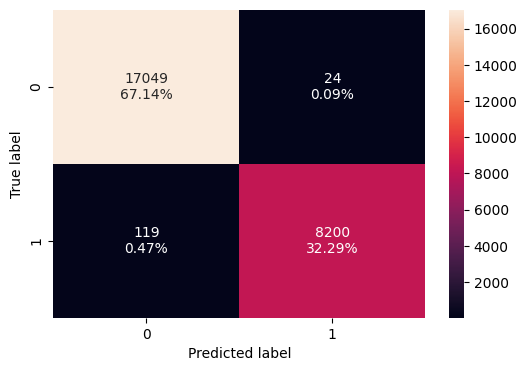

In [448]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [449]:
decision_tree_perf_train_without = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_perf_train_without

,Accuracy,Recall,Precision,F1
0,0.99437,0.98570,0.99708,0.99136


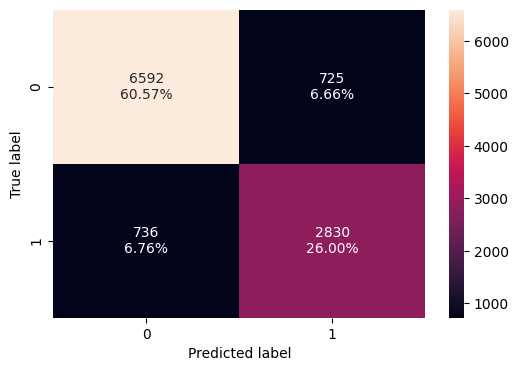

In [450]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [451]:
decision_tree_perf_test_without = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_perf_test_without

,Accuracy,Recall,Precision,F1
0,0.86575,0.79361,0.79606,0.79483


### Decision Tree (with class_weights)

* If the frequency of class A is 10% and the frequency of class B is 90%, then class B will become the dominant class and the decision tree will become biased toward the dominant classes

* In this case, we will set class_weight = "balanced", which will automatically adjust the weights to be inversely proportional to the class frequencies in the input data

* class_weight is a hyperparameter for the decision tree classifier

In [452]:
model = DecisionTreeClassifier(
    class_weight="balanced", random_state=1
)
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

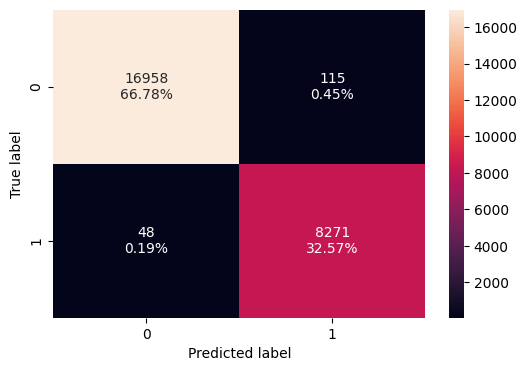

In [453]:
confusion_matrix_sklearn(model, X_train, y_train)

In [454]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,0.99358,0.99423,0.98629,0.99024


* Model is able to perfectly classify all the data points on the training set.
* As we know a decision tree will continue to grow and classify each data point correctly if no restrictions are applied as the trees will learn all the patterns in the training set.
* This generally leads to overfitting of the model as Decision Tree will perform well on the training set but will fail to replicate the performance on the test set.

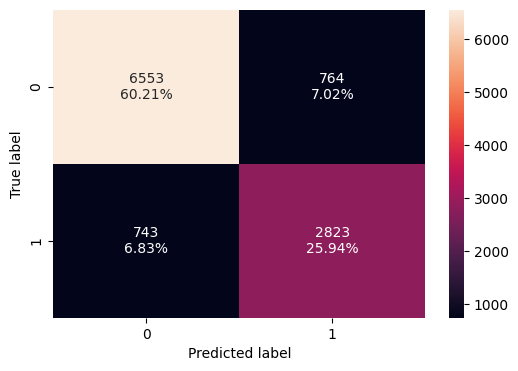

In [455]:
confusion_matrix_sklearn(model, X_test, y_test)

In [456]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.86153,0.79164,0.78701,0.78932


* There is a huge disparity in performance of model on training set and test set, which suggests that the model is overfiiting.

## Do we need to prune the tree?

**Let's use pruning techniques to try and reduce overfitting.**

### Decision Tree (Pre-pruning)

**Using GridSearch for Hyperparameter tuning of our tree model**

* Hyperparameter tuning is also tricky in the sense that there is no direct way to calculate how a change in the
  hyperparameter value will reduce the loss of your model, so we usually resort to experimentation. i.e we'll use Grid search
* Grid search is a tuning technique that attempts to compute the optimum values of hyperparameters.
* It is an exhaustive search that is performed on the specific parameter values of a model.
* The parameters of the estimator/model used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

In [457]:
# choosing the type of classifier
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "class_weight": [None, "balanced"],
    "max_depth": np.arange(2, 7, 2),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}

# type of scoring used to compare parameter combinations
acc_scorer = make_scorer(accuracy_score)

# run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# fit the best algorithm to the data
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=50, min_samples_split=10,
                       random_state=1)

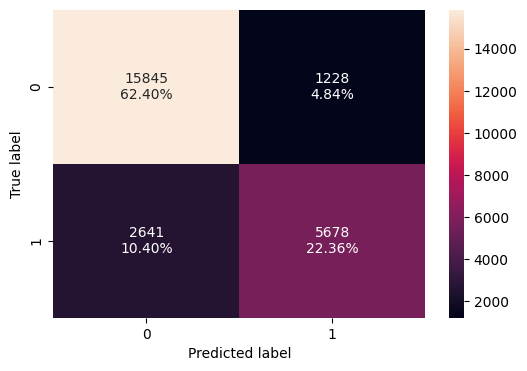

In [458]:
confusion_matrix_sklearn(estimator, X_train, y_train)

In [459]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    estimator, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.84763,0.68253,0.82218,0.74588


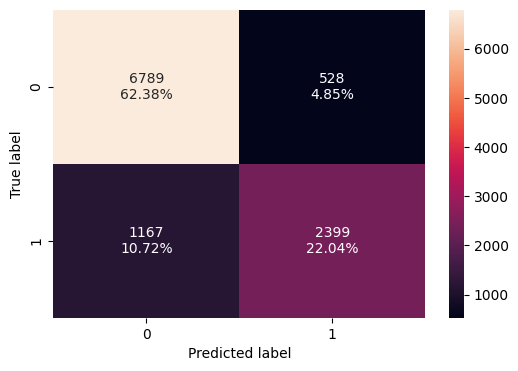

In [460]:
confusion_matrix_sklearn(estimator, X_test, y_test)

In [461]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.84425,0.67274,0.81961,0.73895


* The model is giving a generalized result now since the recall scores on both the train and test data are coming to be between 0.67 and 0.68 which shows that the model is able to generalize well on unseen data.

### Visualizing the Decision Tree

In [462]:
feature_names = list(X_train.columns)
importances = estimator.feature_importances_
indices = np.argsort(importances)

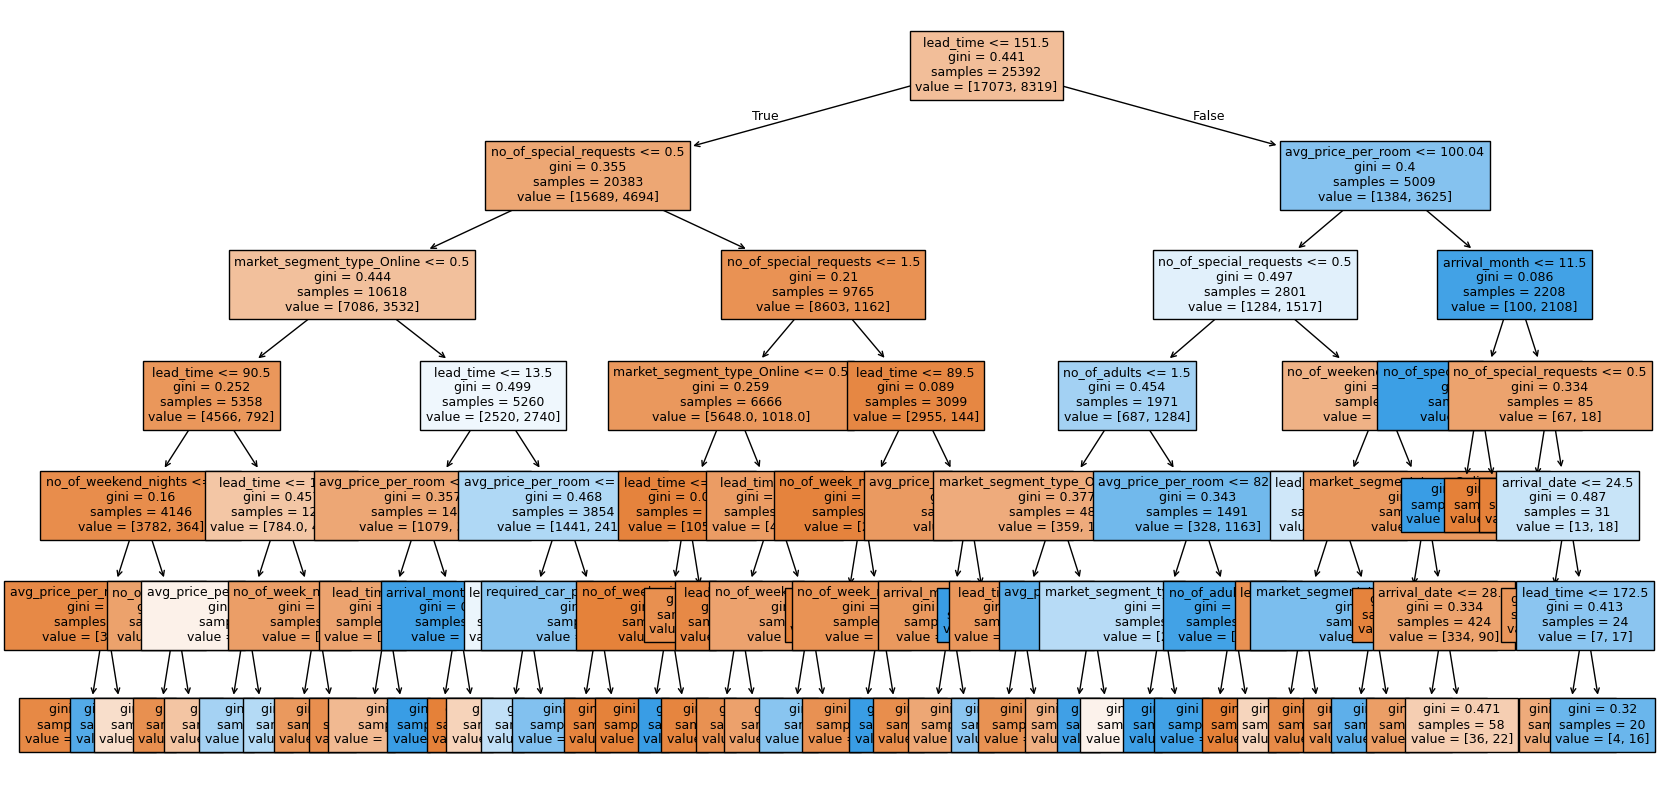

In [463]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [464]:
# Text report showing the rules of a decision tree -
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- no_of_weekend_nights <= 1.50
|   |   |   |   |   |--- avg_price_per_room <= 202.00
|   |   |   |   |   |   |--- weights: [3169.00, 191.00] class: 0
|   |   |   |   |   |--- avg_price_per_room >  202.00
|   |   |   |   |   |   |--- weights: [2.00, 15.00] class: 1
|   |   |   |   |--- no_of_weekend_nights >  1.50
|   |   |   |   |   |--- no_of_adults <= 1.50
|   |   |   |   |   |   |--- weights: [140.00, 103.00] class: 0
|   |   |   |   |   |--- no_of_adults >  1.50
|   |   |   |   |   |   |--- weights: [471.00, 55.00] class: 0
|   |   |   |--- lead_time >  90.50
|   |   |   |   |--- lead_time <= 116.50
|   |   |   |   |   |--- avg_price_per_room <= 93.58
|   |   |   |   |   |   |--- weights: [274.00, 147.00] class: 0
|   |   |   |   |   |--- avg_price_per_room >  93.58
|   |   |   |   |   |   |--- weights: [101.00, 186.

**Observations from the pre-pruned tree:**

Using the above extracted decision rules we can make interpretations from the decision tree model like:

* If the lead time is greater than 151.5, the average price per room is greater than 100.4, the arrival month is less than or equal to 11.5, the number of special requests is less than or equal to 2.5, then the guest is most likey to cancel their booking.

`Interpretations from other decision rules can be made similarly`

In [465]:
importances = estimator.feature_importances_
importances

array([0.        , 0.0444008 , 0.        , 0.01923533, 0.00559688,
       0.00735989, 0.47480164, 0.        , 0.01891829, 0.00129537,
       0.        , 0.        , 0.        , 0.12316828, 0.13480767,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.17041585])

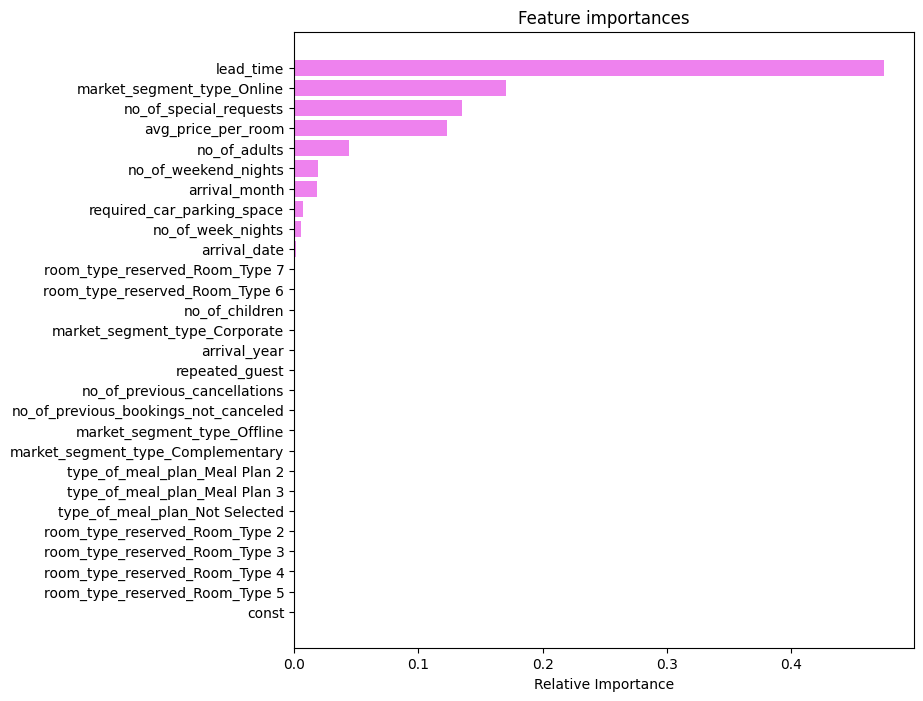

In [466]:
# importance of features in the tree building

importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* In the pre-tuned decision tree lead time lead time is the most important feature.

### Decision Tree (Post pruning)

The DecisionTreeClassifier provides parameters such as min_samples_leaf and max_depth to prevent a tree from overfiting. Cost complexity pruning provides another option to control the size of a tree. In DecisionTreeClassifier, this pruning technique is parameterized by the cost complexity parameter, ccp_alpha. Greater values of ccp_alpha increase the number of nodes pruned.

**Total impurity of leaves vs effective alphas of pruned tree**

Minimal cost complexity pruning recursively finds the node with the "weakest
link". The weakest link is characterized by an effective alpha, where the
nodes with the smallest effective alpha are pruned first. To get an idea of
what values of ``ccp_alpha`` could be appropriate, scikit-learn provides
`DecisionTreeClassifier.cost_complexity_pruning_path` that returns the
effective alphas and the corresponding total leaf impurities at each step of
the pruning process. As alpha increases, more of the tree is pruned, which
increases the total impurity of its leaves.

In [467]:
clf = DecisionTreeClassifier(random_state=1, class_weight='balanced')
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [468]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.00000,0.00833
1,-0.00000,0.00833
2,0.00000,0.00833
3,0.00000,0.00833
4,0.00000,0.00833
...,...,...
1645,0.00938,0.32791
1646,0.00941,0.33732
1647,0.01253,0.34985
1648,0.03405,0.41794


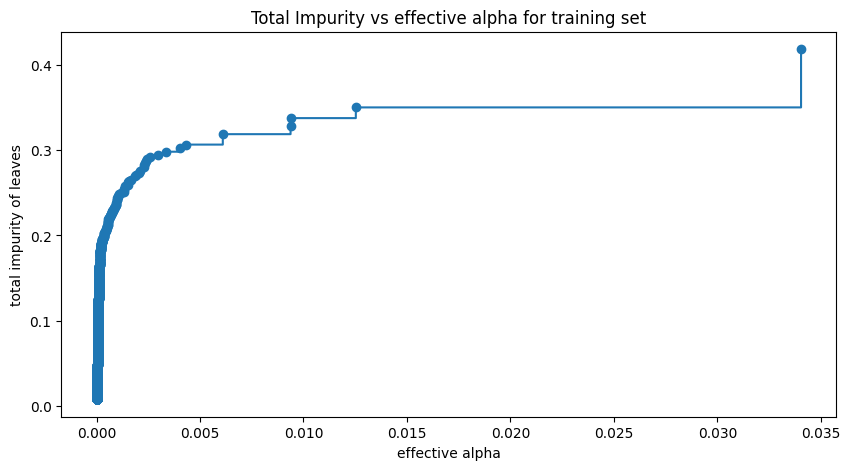

In [469]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using the effective alphas. The last value in ccp_alphas is the alpha value that prunes the whole tree, leaving the tree, clfs[-1], with one node.

In [326]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08205938055988521


For the remainder, we remove the last element in clfs and ccp_alphas, because it is the trivial tree with only one node. Here we show that the number of nodes and tree depth decreases as alpha increases.

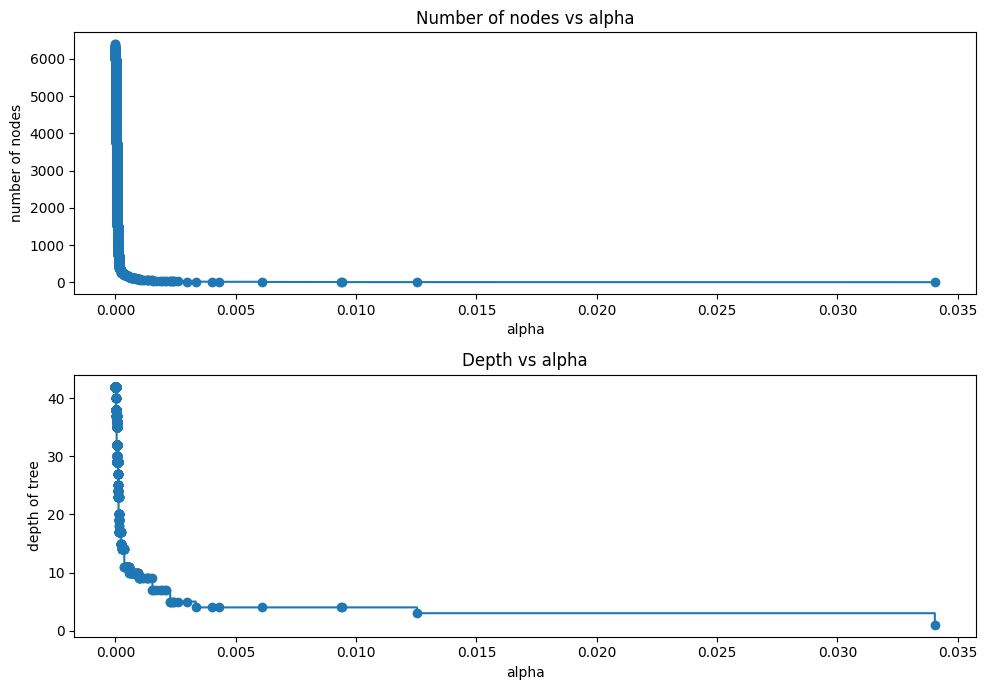

In [470]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [471]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [472]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [473]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

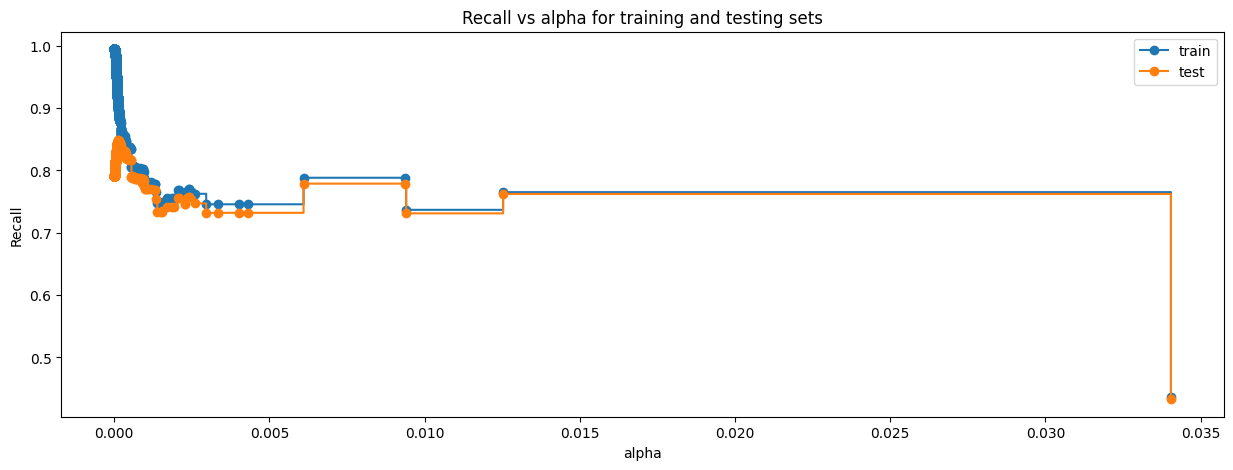

In [474]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [475]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=0.00013683395443351933,
                       class_weight='balanced', random_state=1)


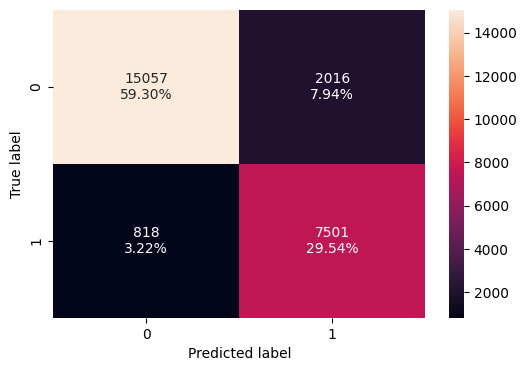

In [476]:
confusion_matrix_sklearn(best_model, X_train, y_train)

In [477]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.88839,0.90167,0.78817,0.84111


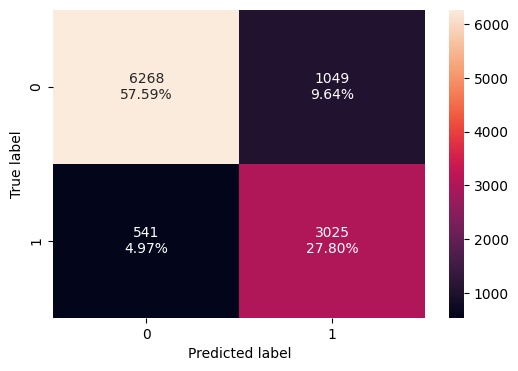

In [478]:
confusion_matrix_sklearn(best_model, X_test, y_test)

In [479]:
decision_tree_post_test = model_performance_classification_sklearn(
    best_model, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.85390,0.84829,0.74251,0.79188


* In the post-pruned tree also, the model is giving a generalized result since the recall scores on the train and test data are 0.90 and 0.85, respectively, which shows that the model is able to generalize well on unseen data.

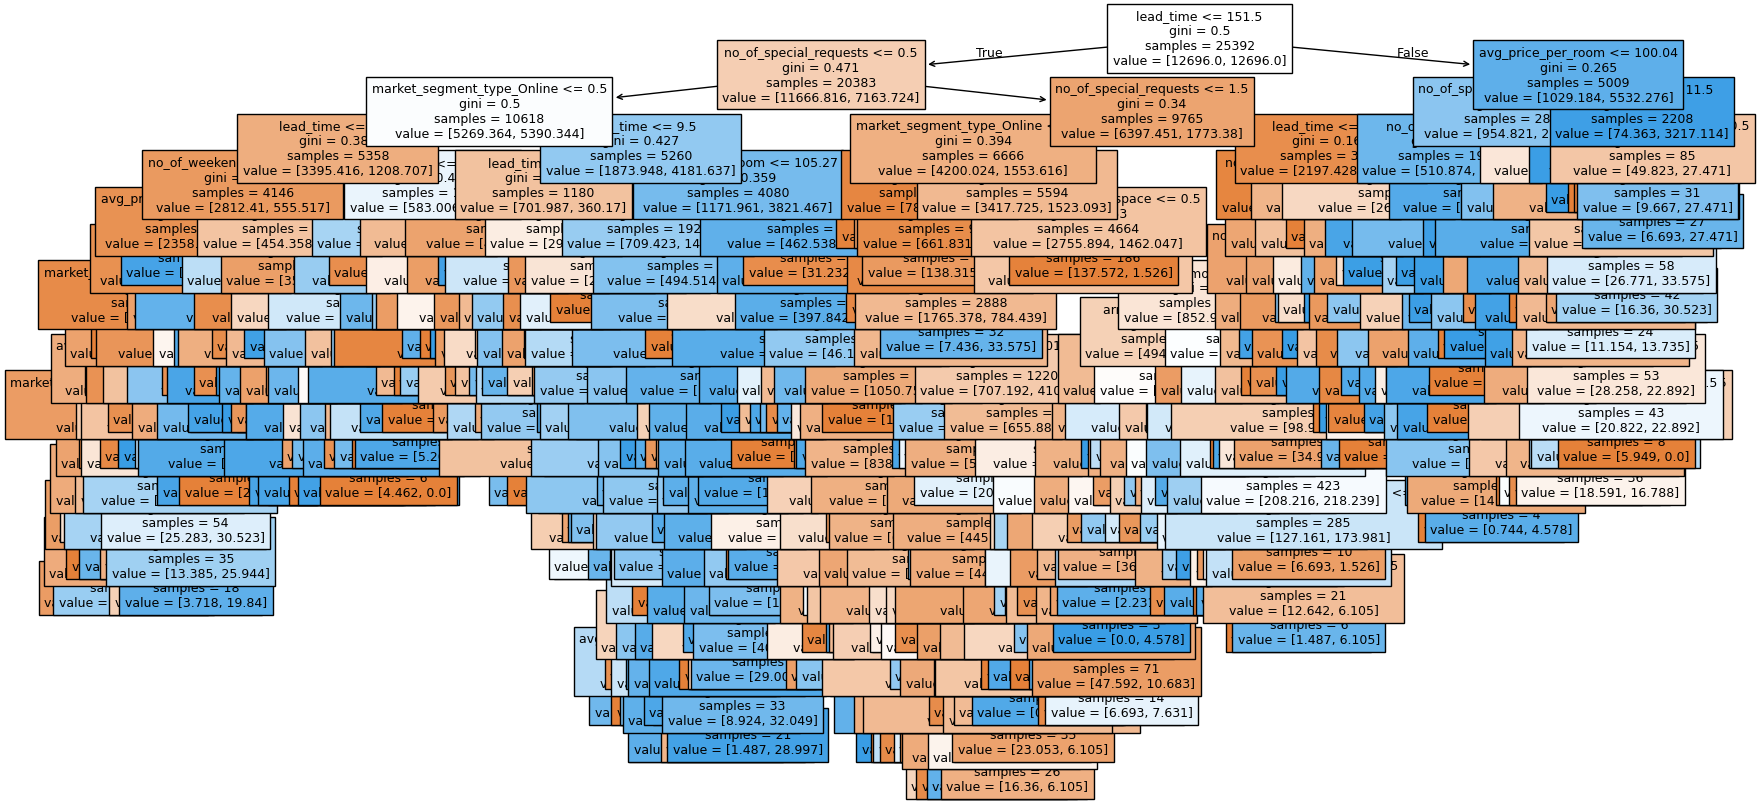

In [480]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [481]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- no_of_weekend_nights <= 1.50
|   |   |   |   |   |--- avg_price_per_room <= 202.00
|   |   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |   |--- repeated_guest <= 0.50
|   |   |   |   |   |   |   |   |   |--- avg_price_per_room <= 87.25
|   |   |   |   |   |   |   |   |   |   |--- market_segment_type_Corporate <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [54.29, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |   |--- market_segment_type_Corporate >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |--- avg_price_per_room >  87.25
|   |   |   |   |   |   |   |   |   |   |--- lead_time <= 1.50
|   |   |   |   |   |   |   |   |  

* We can see that the observation we got from the pre-pruned tree is also matching with the decision tree rules of the post pruned tree.

In [482]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

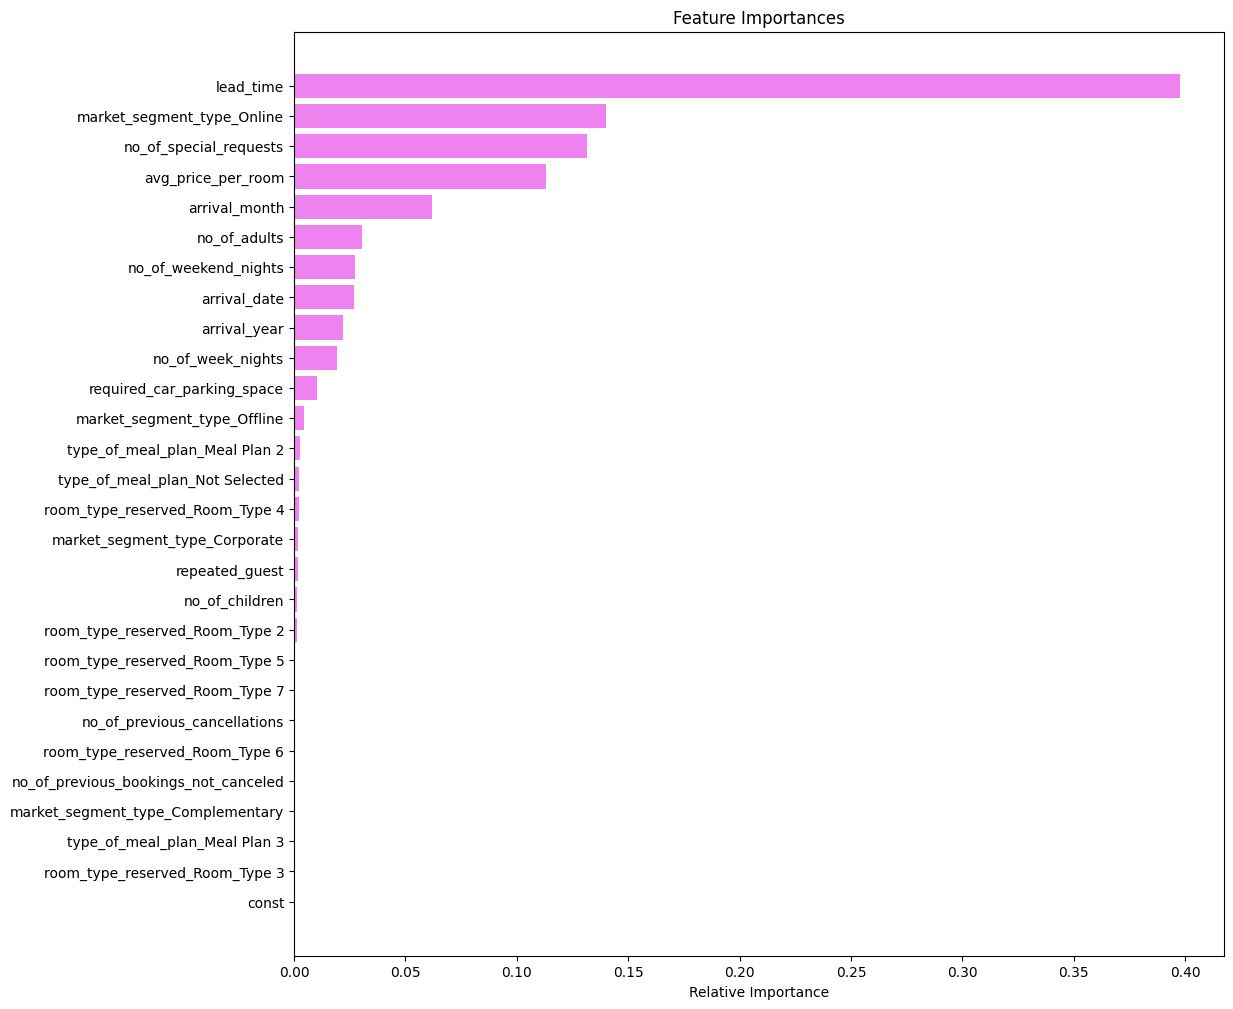

In [483]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Lead time is the most important features for the post pruned tree.

## Model Performance Comparison and Conclusions

In [484]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train_without.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree without class_weight",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree without class_weight,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.99437,0.99358,0.84763,0.88839
Recall,0.98570,0.99423,0.68253,0.90167
Precision,0.99708,0.98629,0.82218,0.78817
F1,0.99136,0.99024,0.74588,0.84111


In [485]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test_without.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree without class_weight",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree without class_weight,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.86575,0.86153,0.84425,0.85390
Recall,0.79361,0.79164,0.67274,0.84829
Precision,0.79606,0.78701,0.81961,0.74251
F1,0.79483,0.78932,0.73895,0.79188


* Decision tree with post-pruning is giving the highest recall on the test set whereas decision tree with class weight is giving the highest recall on the training set.
* We will choose the post-pruned tree as the best model since its recall score is higher than that for decision tree with class weight.

## Actionable Insights and Recommendations

- What profitable policies for cancellations and refunds can the hotel adopt?
- What other recommedations would you suggest to the hotel?

* The model built can be used to predict if a guest is going to cancel their booking or not and can correctly identify 84.8% of the booking cancellations.

  **-> The hotel should implement the predictive model to reduce booking cancellation and increase profits immediately**

* Almost one-third (or 32.8%) of the guests canceled their booking.
  
  **-> Identify high-risk bookings early based on lead time, market segment, and other predictors and allocate resources for reselling the high-risk bookings proactively**
* Only 1.7% of repeating guests cancel their booking, whereas 33.6% of nonrepeating guests cancel their booking.

  **-> Create stricter cancellation policies for non-repeating guests.**
* Lead time is by far the most important variable in predicting whether a guest will cancel their booking or not. Bookings that are canceled have longer mean lead time than those that are not canceled.

  **->For long lead times (high cancellation risk), enforce stricter terms or request partial deposits.**
* Online has the highest percentage of the total market segment types at 64.0%.

  **->Develop marketing strategies to maximize the booking revenues from online market segment.**
* Guests with no special_requests had the highest rate of cancellation followed by guests with 1 and 2 special_requests, whereas guests with 3 or more special requests did not cancel their booking.

  **->Encourage guests to make 3 or more special requests during booking.**
* Online segment has the highest average price per room both with and without outliers. This segment also has the biggest range of average price per room.

  **->Offer more dynamic pricing and special discounts according to the market to induce more booking and fewer cancellation.**
* August, Septempter, and October are the busiest months for the hotel, whereas January through March are the slowest months.

  **->Offer more special offers and discounts during the slow months to induce more booking.**